In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import accuracy_score,r2_score,mean_squared_error,mean_absolute_error

In [ ]:
df=pd.read_csv("Automobile_data.csv")
pd.set_option("display.max_columns",26)
df

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,2952,ohc,four,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,188.8,68.8,55.5,3049,ohc,four,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3012,ohcv,six,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3217,ohc,six,145,idi,3.01,3.4,23.0,106,4800,26,27,22470


In [ ]:
df.shape

(205, 26)

In [ ]:
df.head(10)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,177.3,66.3,53.1,2507,ohc,five,136,mpfi,3.19,3.4,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,192.7,71.4,55.7,2844,ohc,five,136,mpfi,3.19,3.4,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,192.7,71.4,55.7,2954,ohc,five,136,mpfi,3.19,3.4,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,192.7,71.4,55.9,3086,ohc,five,131,mpfi,3.13,3.4,8.3,140,5500,17,20,23875
9,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,178.2,67.9,52.0,3053,ohc,five,131,mpfi,3.13,3.4,7.0,160,5500,16,22,?


In [ ]:
df.tail(10)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
195,-1,74,volvo,gas,std,four,wagon,rwd,front,104.3,188.8,67.2,57.5,3034,ohc,four,141,mpfi,3.78,3.15,9.5,114,5400,23,28,13415
196,-2,103,volvo,gas,std,four,sedan,rwd,front,104.3,188.8,67.2,56.2,2935,ohc,four,141,mpfi,3.78,3.15,9.5,114,5400,24,28,15985
197,-1,74,volvo,gas,std,four,wagon,rwd,front,104.3,188.8,67.2,57.5,3042,ohc,four,141,mpfi,3.78,3.15,9.5,114,5400,24,28,16515
198,-2,103,volvo,gas,turbo,four,sedan,rwd,front,104.3,188.8,67.2,56.2,3045,ohc,four,130,mpfi,3.62,3.15,7.5,162,5100,17,22,18420
199,-1,74,volvo,gas,turbo,four,wagon,rwd,front,104.3,188.8,67.2,57.5,3157,ohc,four,130,mpfi,3.62,3.15,7.5,162,5100,17,22,18950
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,2952,ohc,four,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,188.8,68.8,55.5,3049,ohc,four,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3012,ohcv,six,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3217,ohc,six,145,idi,3.01,3.4,23.0,106,4800,26,27,22470
204,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3062,ohc,four,141,mpfi,3.78,3.15,9.5,114,5400,19,25,22625


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

In [ ]:
df.describe()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,10.142537,25.219512,30.751220
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,3.972040,6.542142,6.886443
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,8.600000,19.000000,25.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,9.400000,30.000000,34.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000


### Data Preprocessing

In [ ]:
# DATA PROCESSING
#1. handling null values
#2. handling duplicates
#3.checking for datatypes


In [ ]:
#1.handling null values
df.isnull().sum()

,0
symboling,0
normalized-losses,0
make,0
fuel-type,0
aspiration,0
num-of-doors,0
body-style,0
drive-wheels,0
engine-location,0
wheel-base,0


In [ ]:
#2.HANDLING DUPLICATES
df.duplicated().sum()

np.int64(0)

In [ ]:
#3.checking for datatype
df.dtypes


,0
symboling,int64
normalized-losses,object
make,object
fuel-type,object
aspiration,object
num-of-doors,object
body-style,object
drive-wheels,object
engine-location,object
wheel-base,float64


In [ ]:
df

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,2952,ohc,four,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,188.8,68.8,55.5,3049,ohc,four,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3012,ohcv,six,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3217,ohc,six,145,idi,3.01,3.4,23.0,106,4800,26,27,22470


In [ ]:
# columns_with_wrong_dtypes = ['normalized-losses','bore','stroke','horsepower','peak-rpm','price']

In [ ]:
df=df.replace('?',np.nan)

In [ ]:
df.isnull().sum()

,0
symboling,0
normalized-losses,41
make,0
fuel-type,0
aspiration,0
num-of-doors,2
body-style,0
drive-wheels,0
engine-location,0
wheel-base,0


In [ ]:
## data cleaning 1.normalized-losses

In [ ]:
df['normalized-losses']=df['normalized-losses'].astype('float')

In [ ]:
df['normalized-losses'].nunique()

51

In [ ]:
mean_=df['normalized-losses'].mean()
mean_

np.float64(122.0)

In [ ]:
df['normalized-losses']=df['normalized-losses'].fillna(mean_)


In [ ]:
df['normalized-losses']=df['normalized-losses'].astype('int')

In [ ]:
# data cleaning 2.num-of-doors

In [ ]:
mode_=df['num-of-doors'].mode()[0]
mode_

'four'

In [ ]:
df['num-of-doors']=df['num-of-doors'].fillna(mode_)

In [ ]:
# data cleaning 3.bore

In [ ]:
df['bore']=df['bore'].astype('float')

In [ ]:
mean_=df['bore'].mean()
mean_

np.float64(3.3297512437810943)

In [ ]:
df['bore']=df['bore'].fillna(mean_)

In [ ]:
# data cleaning 4.stroke

In [ ]:
df['stroke']=df['stroke'].astype('float')

In [ ]:
mean_=df['stroke'].mean()
mean_

np.float64(3.255422885572139)

In [ ]:
df['stroke']=df['stroke'].fillna(mean_)

In [ ]:
# data cleaning 5.horsepower

In [ ]:
df['horsepower']=df['horsepower'].astype('float')

In [ ]:
mean_=df['horsepower'].mean()
mean_

np.float64(104.25615763546799)

In [ ]:
df['horsepower']=df['horsepower'].fillna(mean_)

In [ ]:
df['horsepower']=df['horsepower'].astype('int')

In [ ]:
# data cleaning 6.peak-rpm

In [ ]:
df['peak-rpm']=df['peak-rpm'].astype('float')

In [ ]:
mean_=df['peak-rpm'].mean()
mean_

np.float64(5125.369458128079)

In [ ]:
df['peak-rpm']=df['peak-rpm'].fillna(mean_)

In [ ]:
df['peak-rpm']=df['peak-rpm'].astype('int')

In [ ]:
# data cleaning 7.price

In [ ]:
df['price']=df['price'].astype('float')

In [ ]:
mean_=df['price'].mean()
mean_

np.float64(13207.129353233831)

In [ ]:
df['price']=df['price'].fillna(mean_)

In [ ]:
df['price']=df['price'].astype('int')

df.dtypes

In [ ]:
df.isnull().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

In [ ]:
#categorical:symboling(nominal),normalized-losses(nominal),make(ordinal),fuel-type(ordinal),aspiration(ordinal),
                                    #num-of-doors(ordinal),body-style(ordinal),price(nominal),
#numerical:,length(continous),width(continous),height(continous)

### UNIVARIATE ANALYSIS

In [ ]:
#univariate analysis of column symboling
df['symboling'].nunique()

6

In [ ]:
df['symboling'].unique()

array([ 3,  1,  2,  0, -1, -2])

In [ ]:
df['symboling'].value_counts()

symboling
 0    67
 1    54
 2    32
 3    27
-1    22
-2     3
Name: count, dtype: int64

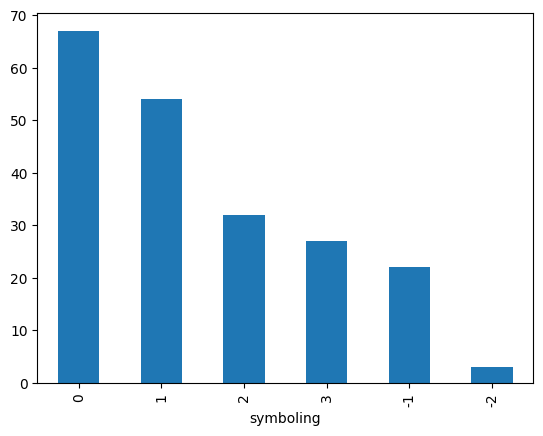

In [ ]:
df['symboling'].value_counts().plot(kind='bar')
plt.show()

In [ ]:
#univariate analysis of column make

In [ ]:
df['make'].nunique()

22

In [ ]:
df['make'].unique()

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'mazda', 'mercedes-benz', 'mercury',
       'mitsubishi', 'nissan', 'peugot', 'plymouth', 'porsche', 'renault',
       'saab', 'subaru', 'toyota', 'volkswagen', 'volvo'], dtype=object)

In [ ]:
df['make'].value_counts()

make
toyota           32
nissan           18
mazda            17
mitsubishi       13
honda            13
subaru           12
volkswagen       12
volvo            11
peugot           11
dodge             9
mercedes-benz     8
bmw               8
audi              7
plymouth          7
saab              6
porsche           5
isuzu             4
alfa-romero       3
chevrolet         3
jaguar            3
renault           2
mercury           1
Name: count, dtype: int64

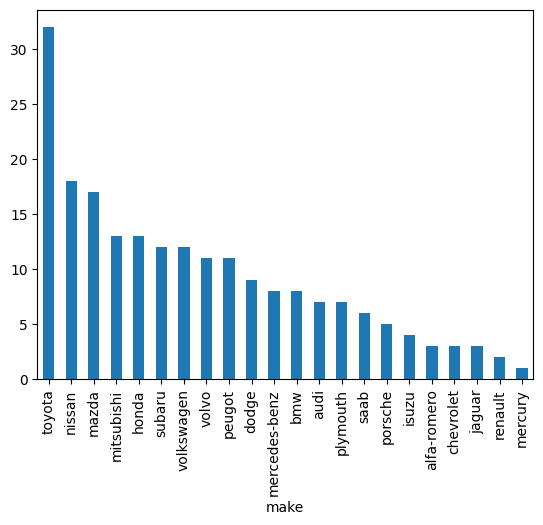

In [ ]:
df['make'].value_counts().plot(kind='bar')
plt.show()

In [ ]:
#univariate analysis of column fuel-type

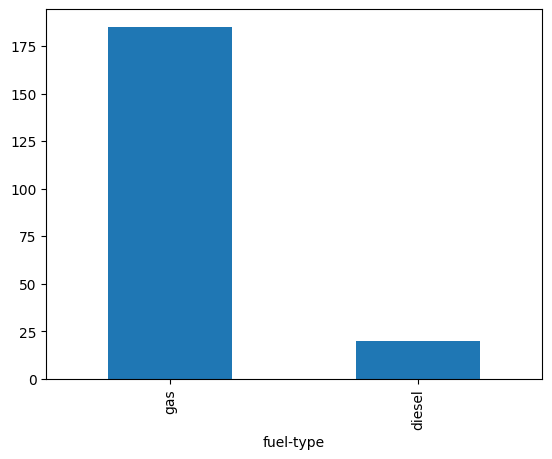

In [ ]:
df['fuel-type'].value_counts().plot(kind='bar')
plt.show()

In [ ]:
#univariate analysis of column aspiration

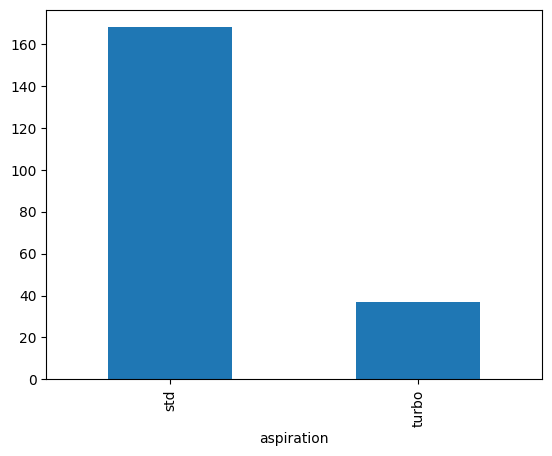

In [ ]:
df['aspiration'].value_counts().plot(kind='bar')
plt.show()

In [ ]:
#univariate analysis of column num-of-doors

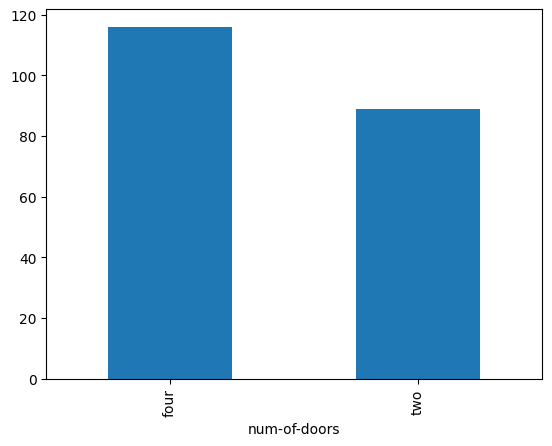

In [ ]:
df['num-of-doors'].value_counts().plot(kind='bar')
plt.show()

In [ ]:
#univariate analysis of column body-style

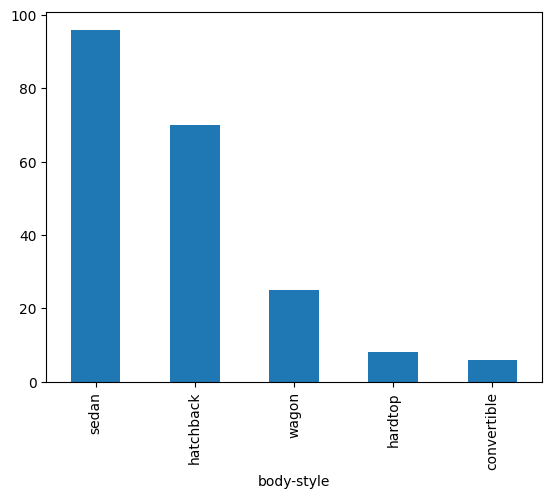

In [ ]:
df['body-style'].value_counts().plot(kind='bar')
plt.show()

In [ ]:
#univariate analysis of column length

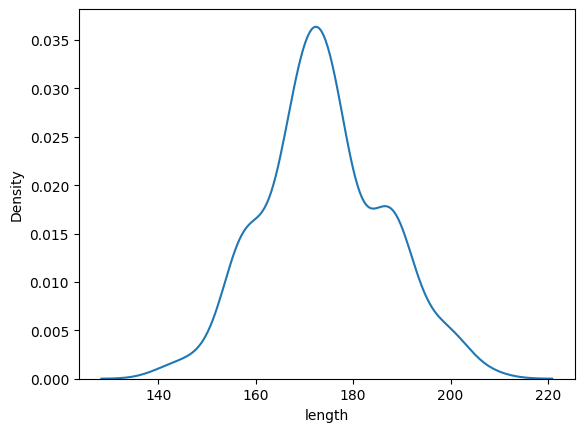

In [ ]:
sns.kdeplot(df['length'])
plt.show()

In [ ]:
#univariate analysis of column width

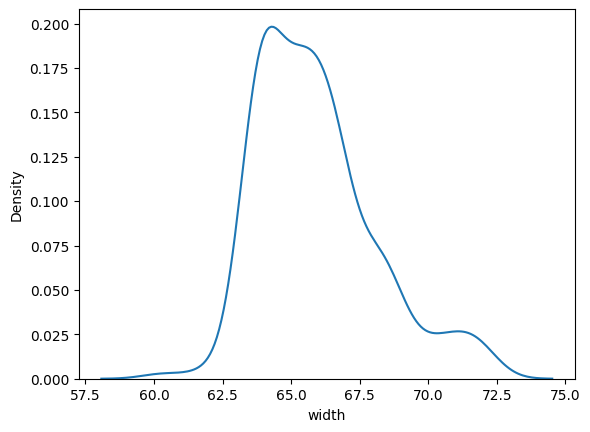

In [ ]:
sns.kdeplot(df['width'])
plt.show()

In [ ]:
#univariate analysis of column height

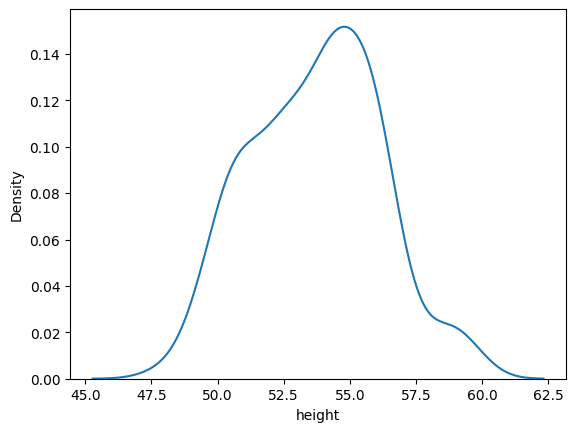

In [ ]:
sns.kdeplot(df['height'])
plt.show()

In [ ]:
#univariate analysis of columns city-mpg

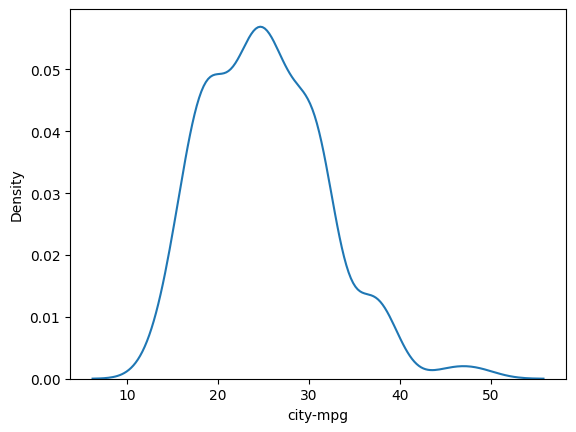

In [ ]:
sns.kdeplot(df['city-mpg'])
plt.show()

In [ ]:
#univariate analysis of column bore

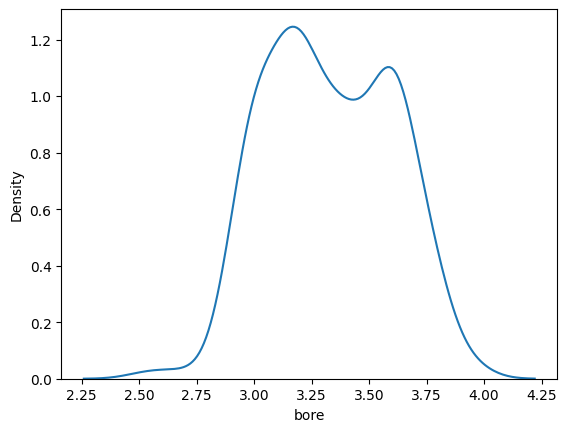

In [ ]:
sns.kdeplot(df['bore'])
plt.show()

In [ ]:
#univariate analysis of column stroke


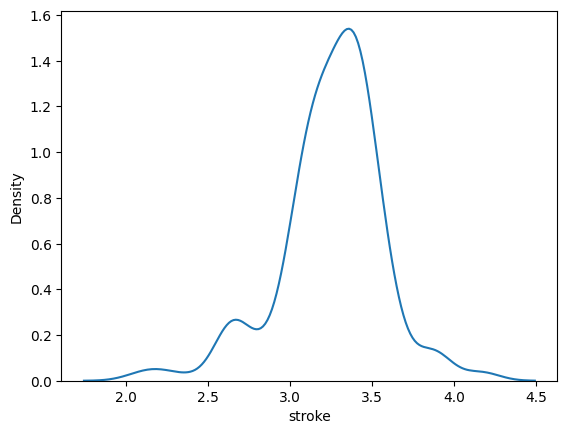

In [ ]:
sns.kdeplot(df['stroke'])
plt.show()

In [ ]:
#univariate analysis of column horsepower

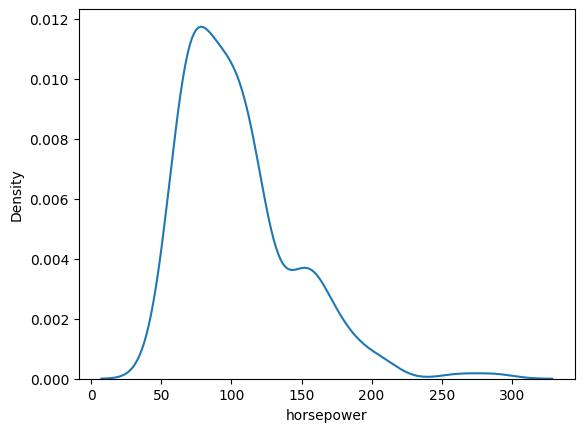

In [ ]:
sns.kdeplot(df['horsepower'])
plt.show()

In [ ]:
#univariate analysis of column drive-wheels

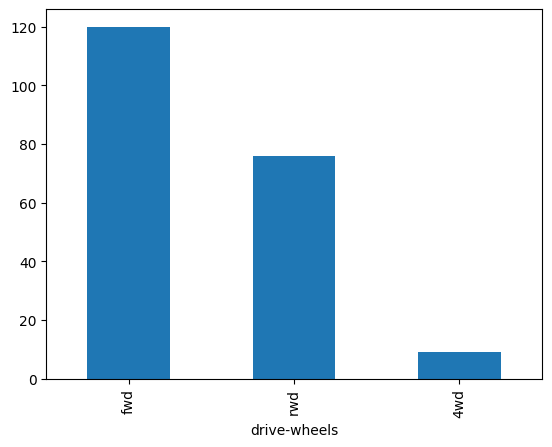

In [ ]:
df['drive-wheels'].value_counts().plot(kind='bar')
plt.show()

In [ ]:
#univariate analysis of column price

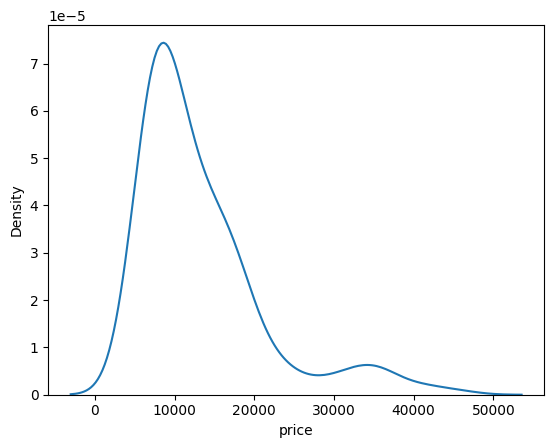

In [ ]:
sns.kdeplot(df['price'])
plt.show()

In [ ]:
#univariate analysis of column curb-weight

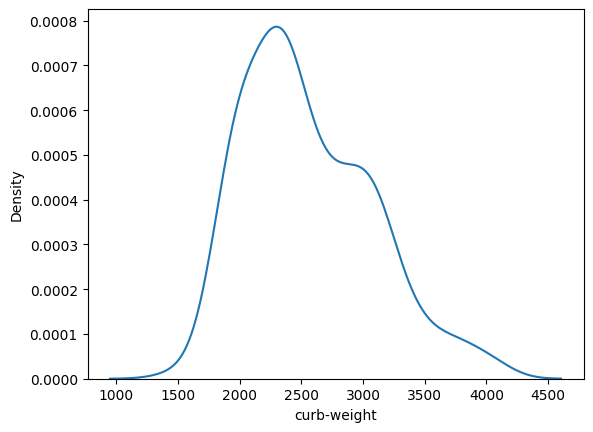

In [ ]:
sns.kdeplot(df['curb-weight'])
plt.show()

In [ ]:
#univariate analysis of column compression-ratio


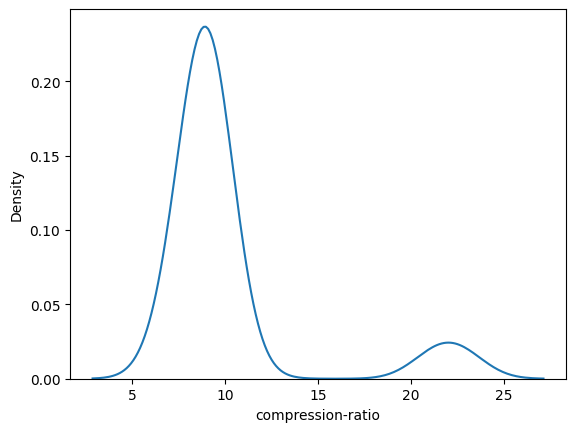

In [ ]:
sns.kdeplot(df['compression-ratio'])
plt.show()

In [ ]:
#univariate analysis of column body-style

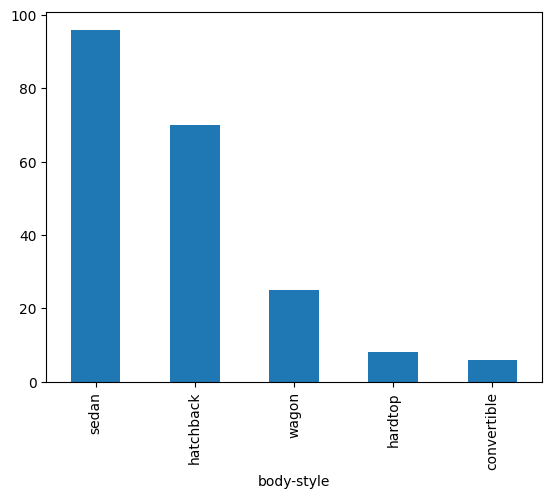

In [ ]:
df['body-style'].value_counts().plot(kind='bar')
plt.show()

In [ ]:
#univariate analysis of column num-of-cylinders

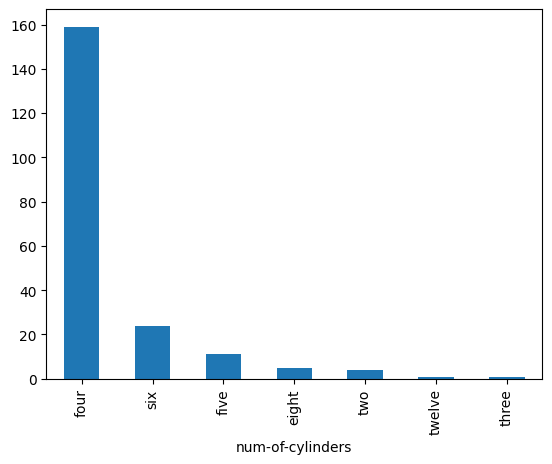

In [ ]:
df['num-of-cylinders'].value_counts().plot(kind='bar')
plt.show()


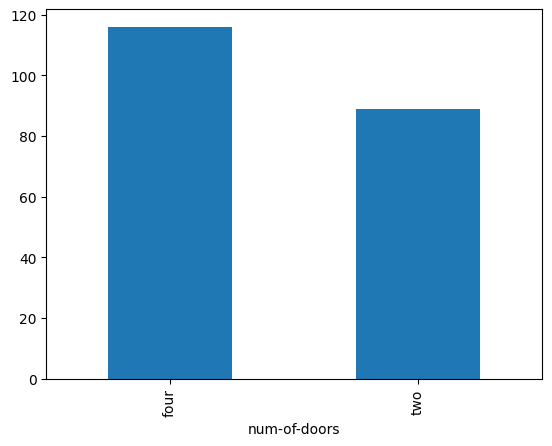

In [ ]:
df['num-of-doors'].value_counts().plot(kind='bar')
plt.show()

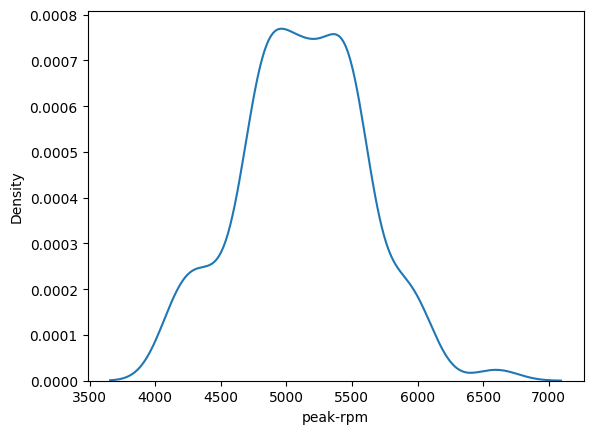

In [ ]:
sns.kdeplot(df['peak-rpm'])
plt.show()

## Bivariate Analysis

In [ ]:
df.dtypes

,0
symboling,int64
normalized-losses,int64
make,object
fuel-type,object
aspiration,object
num-of-doors,object
body-style,object
drive-wheels,object
engine-location,object
wheel-base,float64


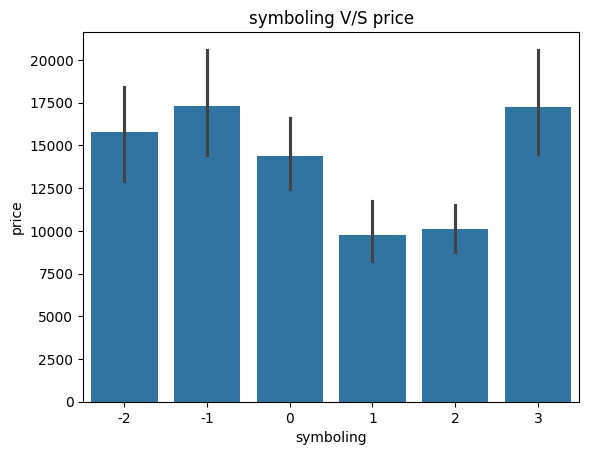

In [ ]:
## Bivariate Anlaysis  of the columns symboling and price

sns.barplot(data=df,x='symboling',y='price')
plt.title("symboling V/S price")
plt.show()

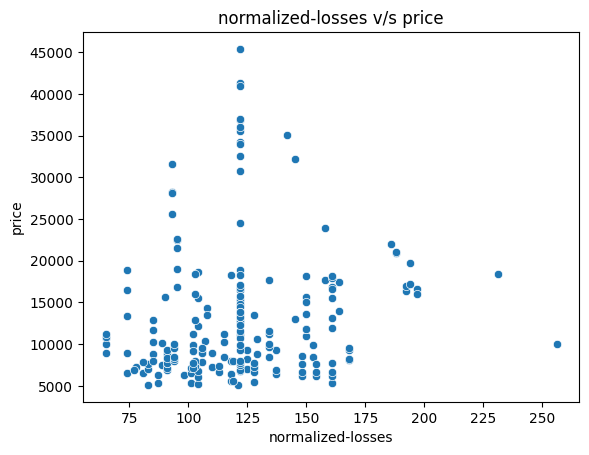

In [ ]:
## Bivariate Anlaysis  of the columns normalised-losses and price
sns.scatterplot(data=df,x='normalized-losses',y='price')
plt.title("normalized-losses v/s price")
plt.show()

In [ ]:
df['normalized-losses'].corr(df['price'])

np.float64(0.13399873429239545)

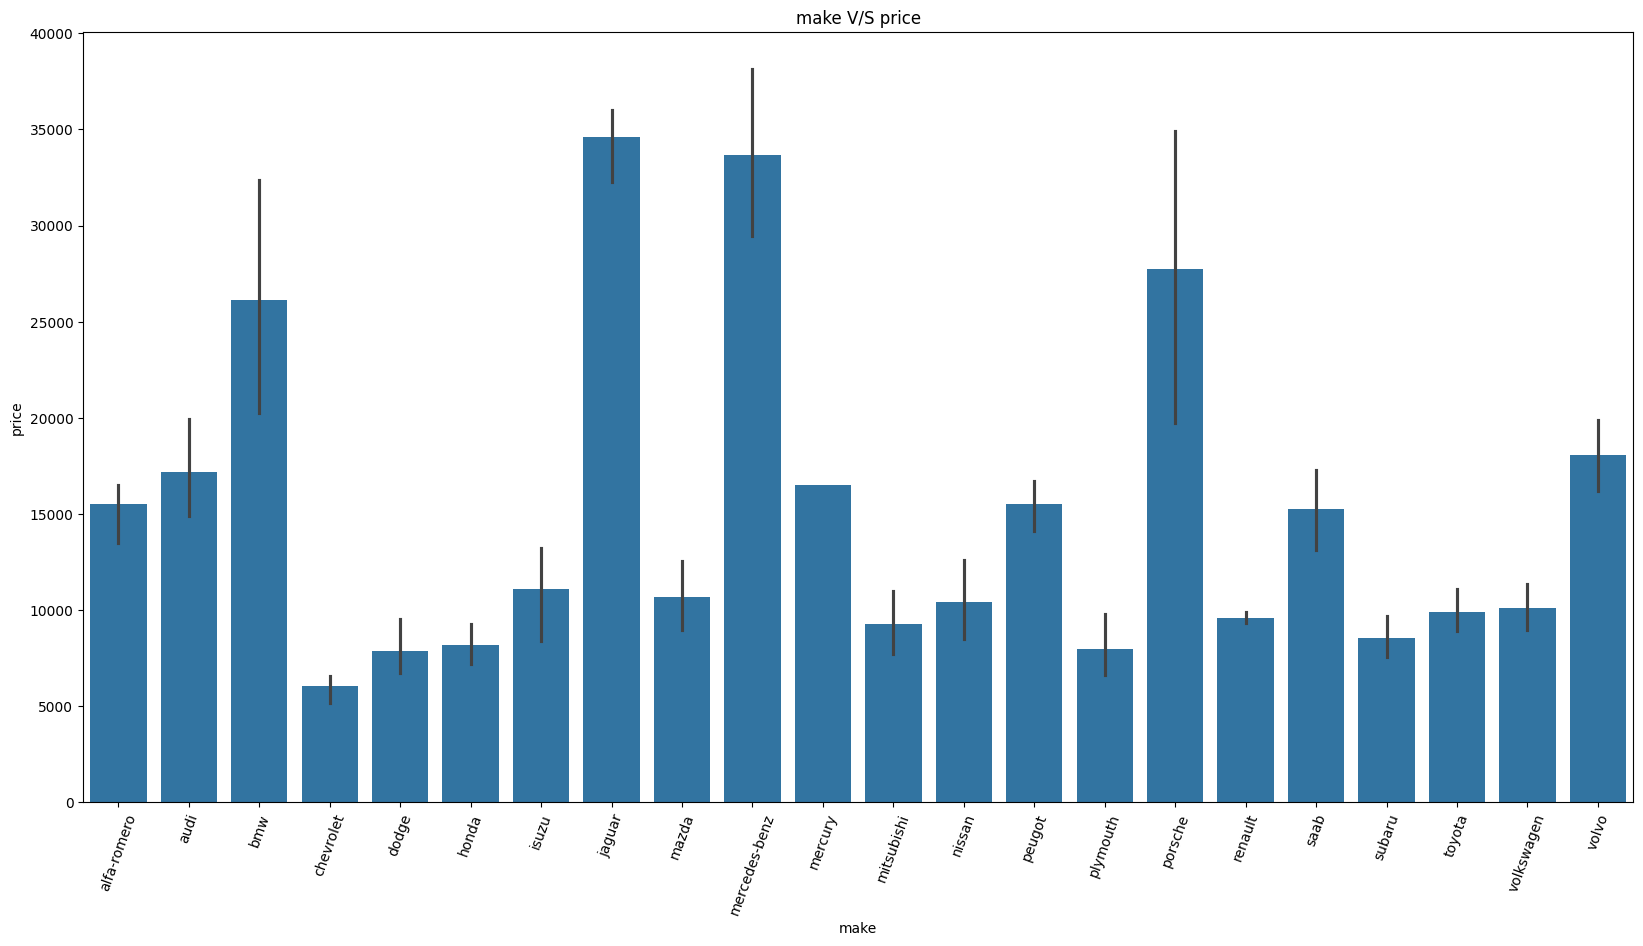

In [ ]:
## Bivariate Anlaysis  of the columns make and charges
plt.figure(figsize=(20,10))
sns.barplot(data=df,x='make',y='price')
plt.title("make V/S price")
plt.xticks(rotation=70)
plt.show()

* Jaguar and mercedes are having the highest average price and chevrolet is at the lowest

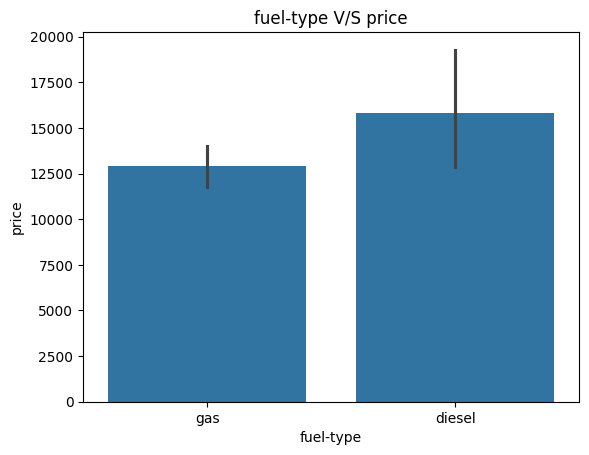

In [ ]:
# Bivariate Anlaysis  of the columns fuel-type and price
sns.barplot(data=df,x='fuel-type',y='price')
plt.title("fuel-type V/S price")
plt.show()

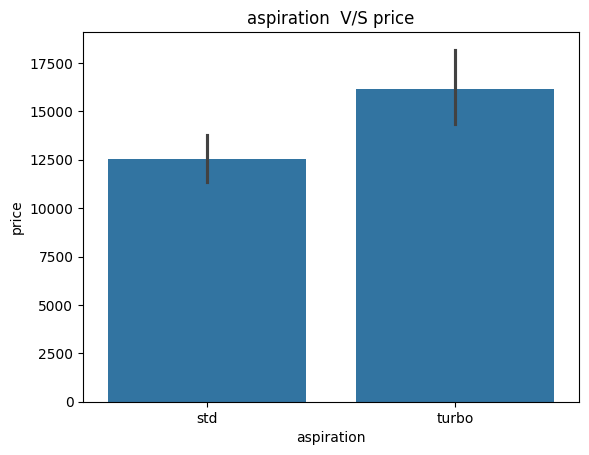

In [ ]:
# Bivariate Anlaysis  of the columns aspiration  and price
sns.barplot(data=df,x='aspiration',y='price')
plt.title("aspiration  V/S price")
plt.show()

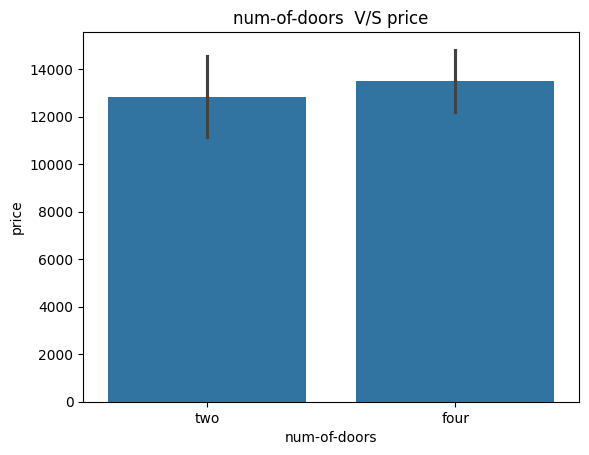

In [ ]:
# Bivariate Anlaysis  of the columns num-of-doors  and price
sns.barplot(data=df,x='num-of-doors',y='price')
plt.title("num-of-doors  V/S price")
plt.show()

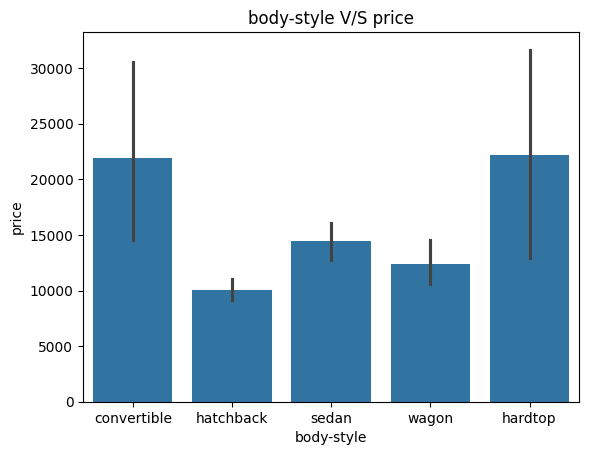

In [ ]:
# Bivariate Anlaysis  of the columns body-style  and price
sns.barplot(data=df,x='body-style',y='price')
plt.title("body-style V/S price")
plt.show()

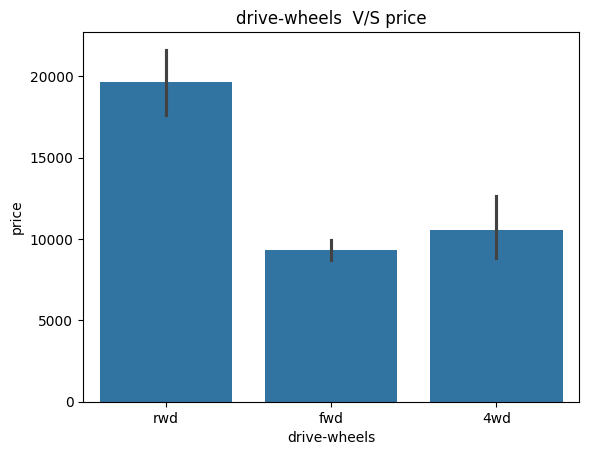

In [ ]:
# Bivariate Anlaysis  of the columns drive-wheels  and price
sns.barplot(data=df,x='drive-wheels',y='price')
plt.title("drive-wheels  V/S price")
plt.show()

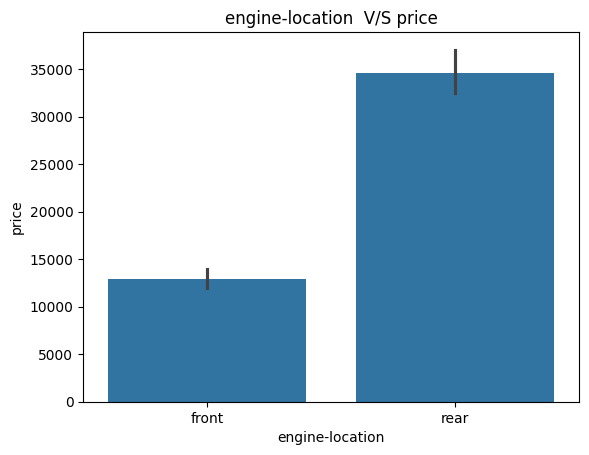

In [ ]:
# Bivariate Anlaysis  of the columns engine-location  and price
sns.barplot(data=df,x='engine-location',y='price')
plt.title("engine-location  V/S price")
plt.show()

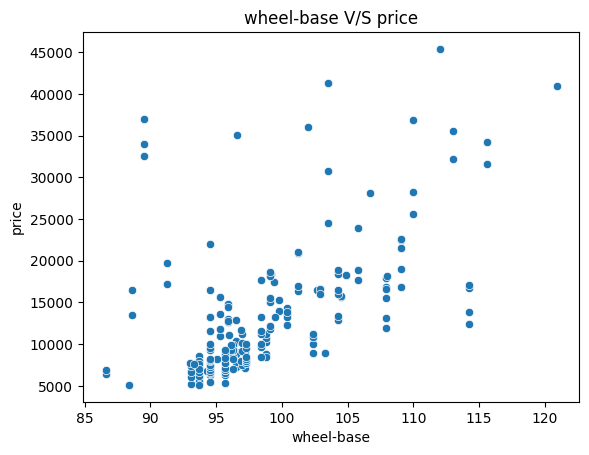

In [ ]:
# Bivariate Anlaysis  of the columns wheel-base  and price
sns.scatterplot(data=df,x='wheel-base',y='price')
plt.title("wheel-base V/S price")
plt.show()

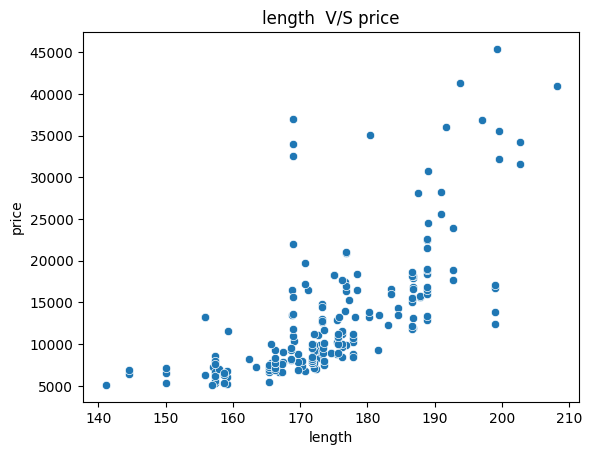

In [ ]:
# Bivariate Anlaysis  of the columns length  and price
sns.scatterplot(data=df,x='length',y='price')
plt.title("length  V/S price")
plt.show()

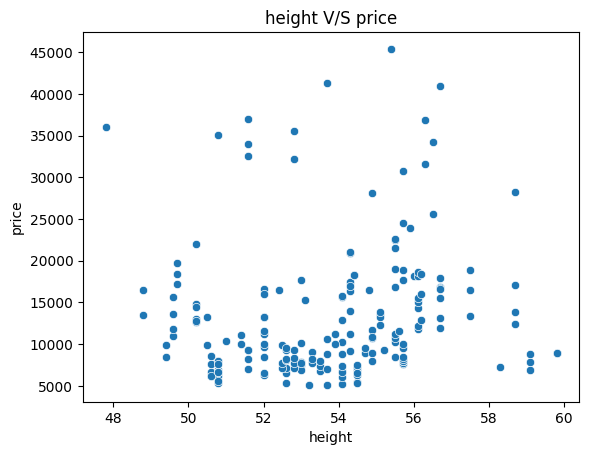

In [ ]:
# Bivariate Anlaysis  of the columns height and price
sns.scatterplot(data=df,x='height',y='price')
plt.title("height V/S price")
plt.show()

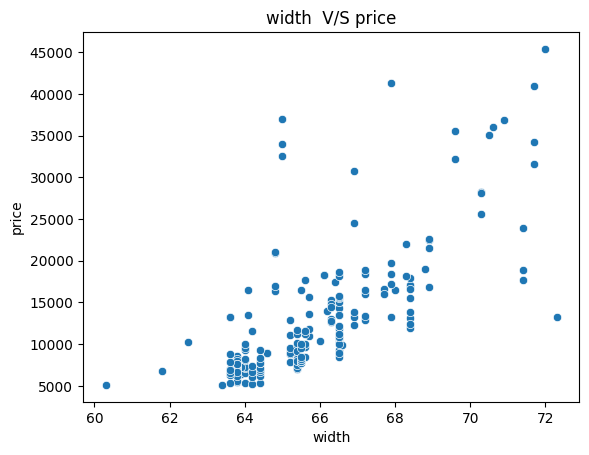

In [ ]:
# Bivariate Anlaysis  of the columns wigth  and price
sns.scatterplot(data=df,x='width',y='price')
plt.title("width  V/S price")
plt.show()

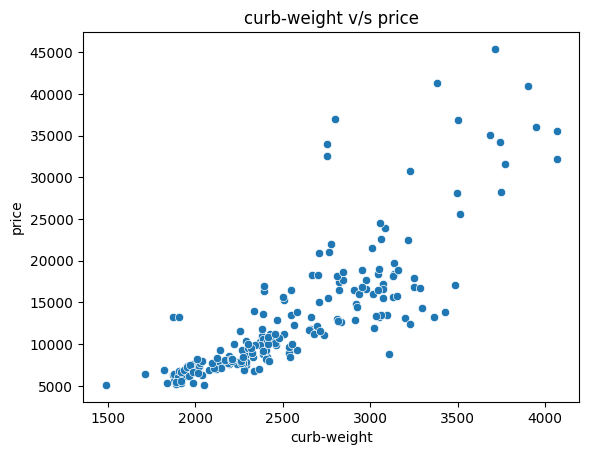

In [ ]:
# Bivariate Anlaysis  of the curb-weight  and price
sns.scatterplot(data=df,x='curb-weight',y='price')
plt.title('curb-weight v/s price')
plt.show()

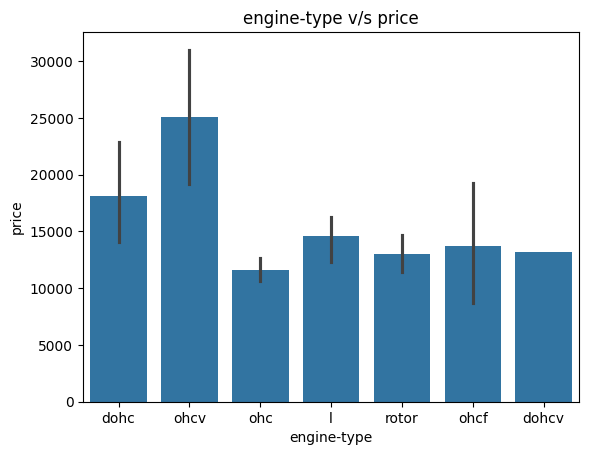

In [ ]:
# Bivariate Anlaysis  of the columns engine-type  and price
sns.barplot(data=df,x='engine-type',y='price')
plt.title('engine-type v/s price')
plt.show()

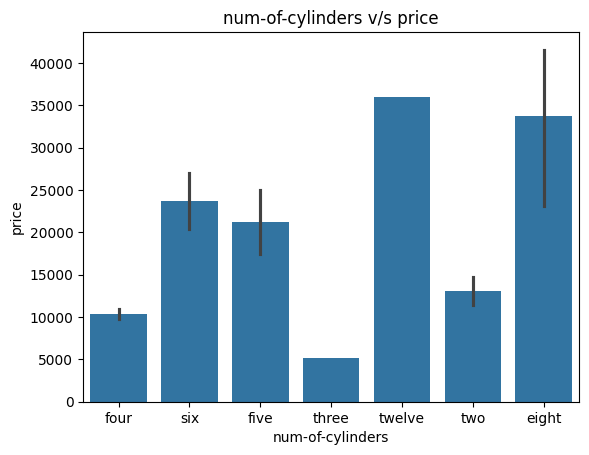

In [ ]:
# Bivariate Anlaysis  of the columns num-of-cylinders  and price
sns.barplot(data=df,x='num-of-cylinders',y='price')
plt.title('num-of-cylinders v/s price')
plt.show()

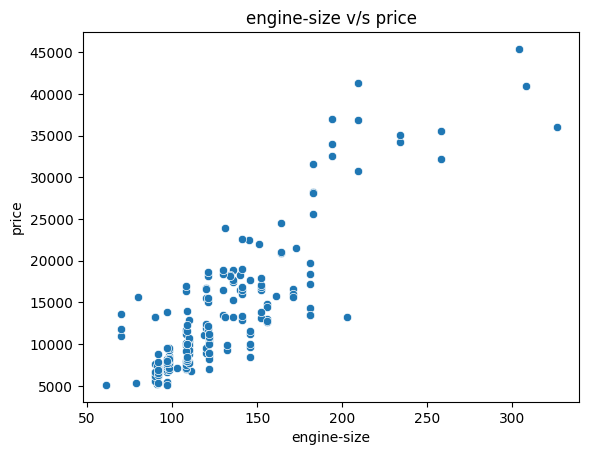

In [ ]:
# Bivariate Anlaysis  of the columns engine-size  and price
sns.scatterplot(data=df,x='engine-size',y='price')
plt.title('engine-size v/s price')
plt.show()

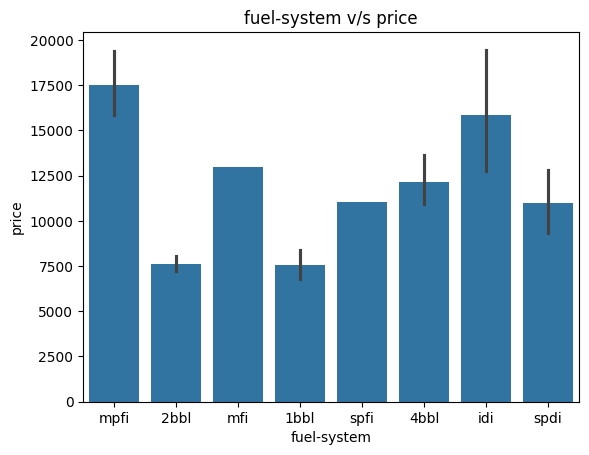

In [ ]:
# Bivariate Anlaysis  of the columns fuel-system  and price
sns.barplot(data=df,x='fuel-system',y='price')
plt.title('fuel-system v/s price')
plt.show()

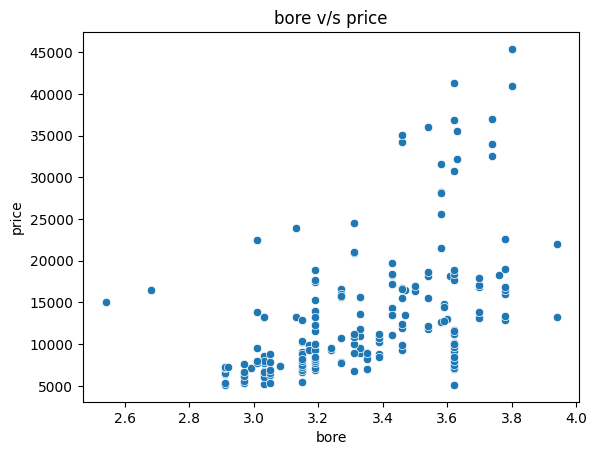

In [ ]:
# Bivariate Anlaysis  of the columns bore  and price
sns.scatterplot(data=df,x='bore',y='price')
plt.title('bore v/s price')
plt.show()

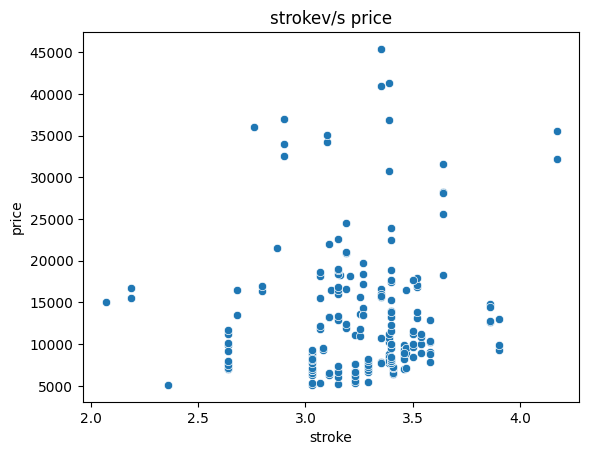

In [ ]:
# Bivariate Anlaysis  of the columns stroke  and price
sns.scatterplot(data=df,x='stroke',y='price')
plt.title('strokev/s price')
plt.show()

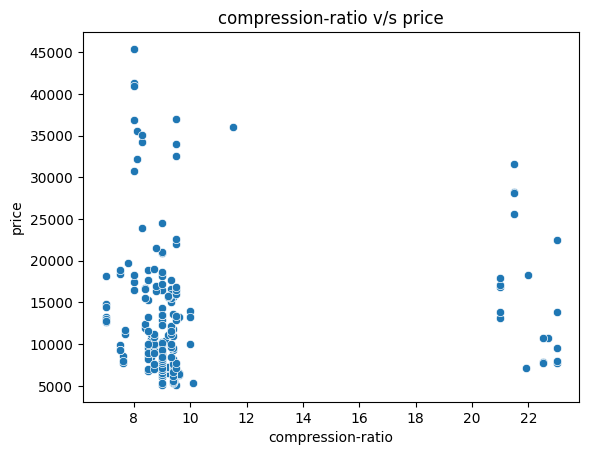

In [ ]:
# Bivariate Anlaysis  of the columns compression-ratios  and price
sns.scatterplot(data=df,x='compression-ratio',y='price')
plt.title('compression-ratio v/s price')
plt.show()

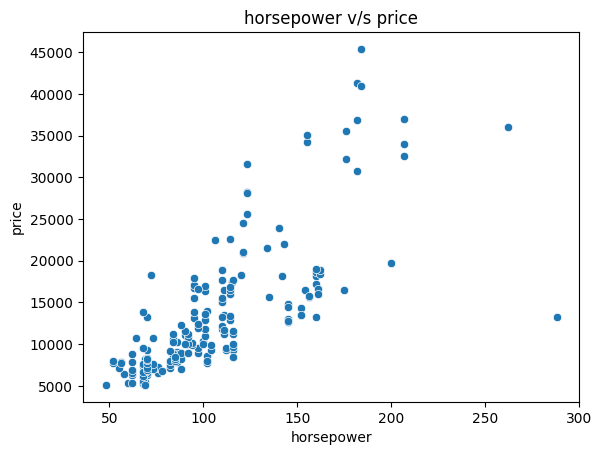

In [ ]:
# Bivariate Anlaysis  of the columns horsepower  and price
sns.scatterplot(data=df,x='horsepower',y='price')
plt.title('horsepower v/s price')
plt.show()

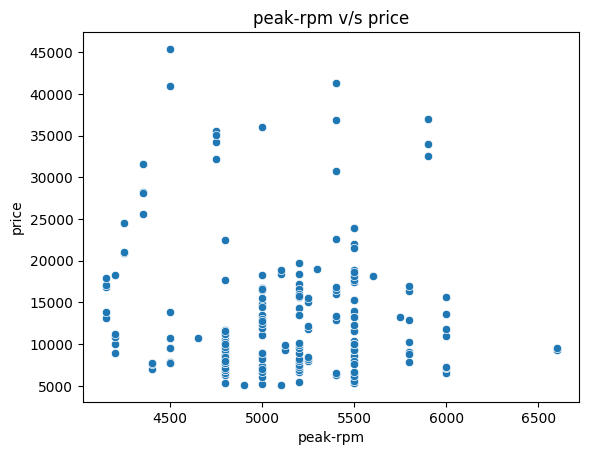

In [ ]:
# Bivariate Anlaysis  of the columns peak-rpm  and price
sns.scatterplot(data=df,x='peak-rpm',y='price')
plt.title('peak-rpm v/s price')
plt.show()

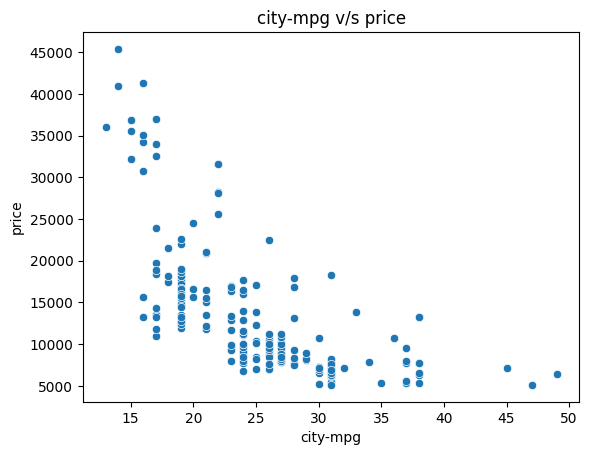

In [ ]:
# Bivariate Anlaysis  of the columns city-mpg  and price
sns.scatterplot(data=df,x='city-mpg',y='price')
plt.title('city-mpg v/s price')
plt.show()

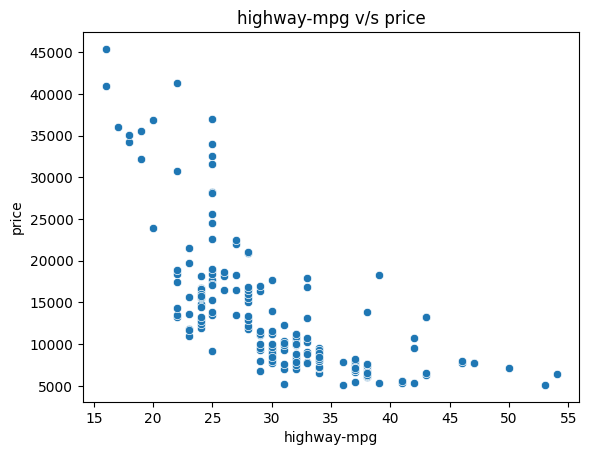

In [ ]:
# Bivariate Anlaysis  of the columns highway-mpg  and price
sns.scatterplot(data=df,x='highway-mpg',y='price')
plt.title('highway-mpg v/s price')
plt.show()

In [ ]:
df

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,2952,ohc,four,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,188.8,68.8,55.5,3049,ohc,four,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3012,ohcv,six,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3217,ohc,six,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


In [ ]:
df['num-of-doors'].value_counts()

num-of-doors
four    116
two      89
Name: count, dtype: int64

### MULTIVARIATE ANALYSIS

In [ ]:
df

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,2952,ohc,four,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,188.8,68.8,55.5,3049,ohc,four,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3012,ohcv,six,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3217,ohc,six,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


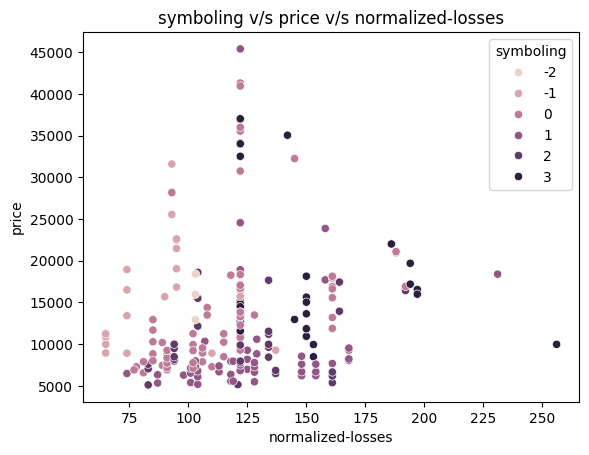

In [ ]:
# multivariate Anlaysis  of the columns symboling,normalized-losses and price
sns.scatterplot(data=df,x='normalized-losses',y='price',hue='symboling')
plt.title('symboling v/s price v/s normalized-losses')
plt.show()

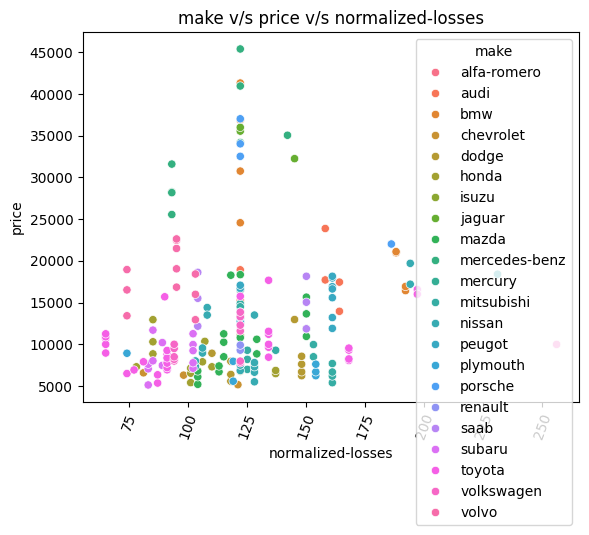

In [ ]:
# multivariate Anlaysis  of the columns make,normalized-losses and price
sns.scatterplot(data=df,x='normalized-losses',y='price',hue='make')
plt.title('make v/s price v/s normalized-losses')
plt.xticks(rotation=70)
plt.show()

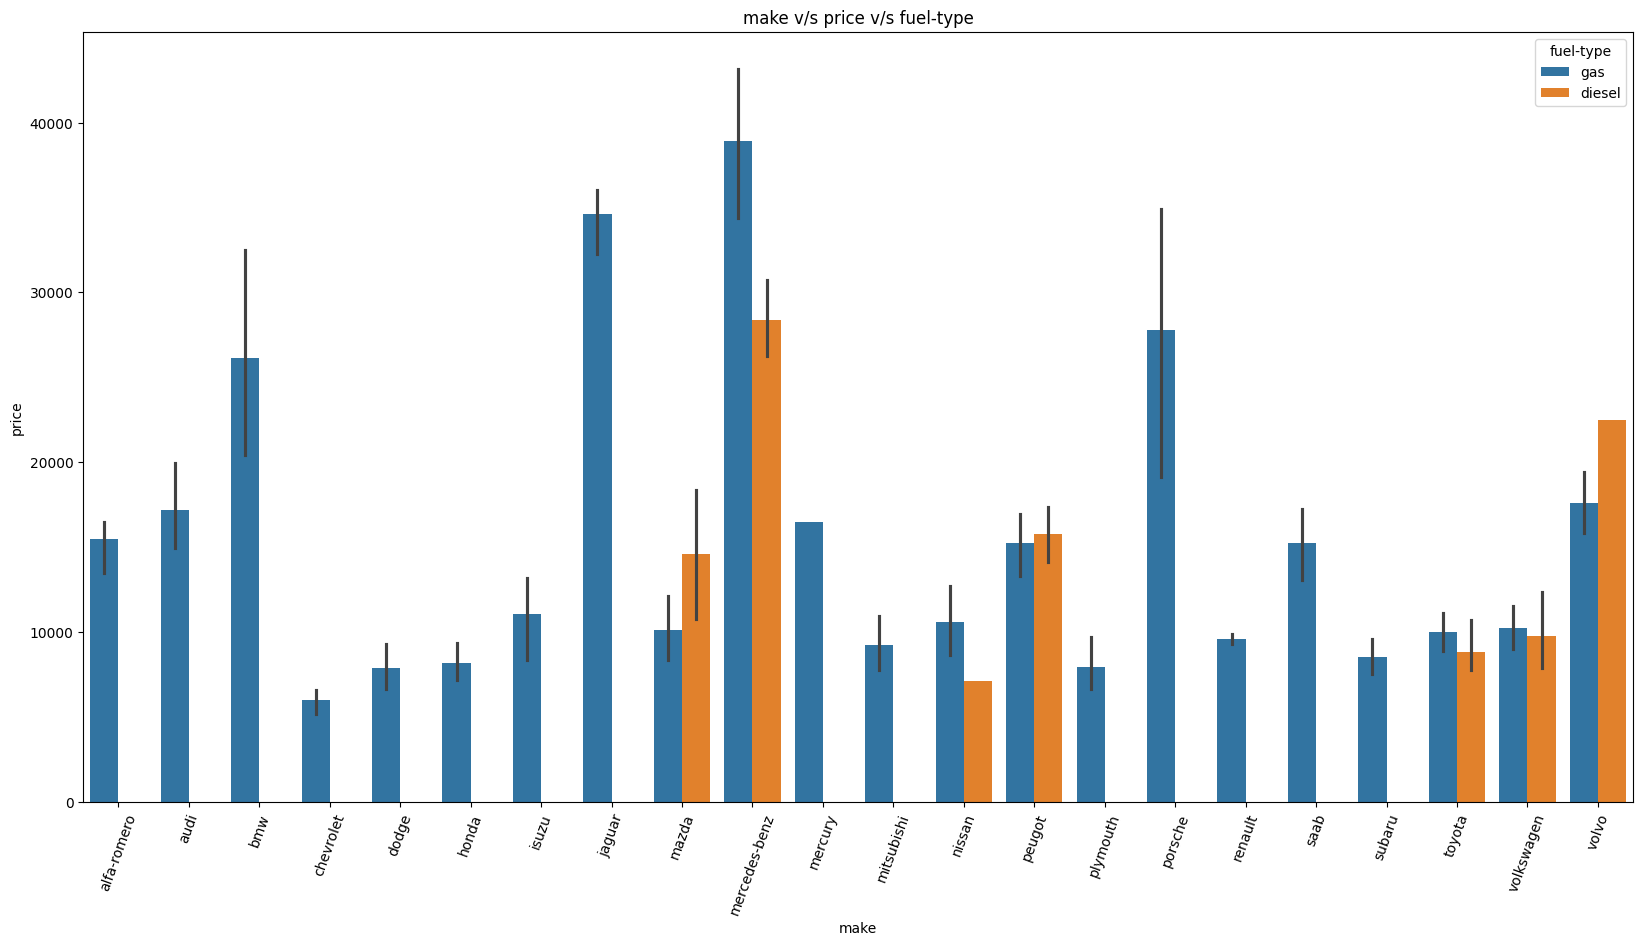

In [ ]:
# multivariate Anlaysis  of the columns make,fuel-type and price
plt.figure(figsize=(20,10))
sns.barplot(data=df,x='make',y='price',hue='fuel-type')
plt.title('make v/s price v/s fuel-type')
plt.xticks(rotation=70)
plt.show()

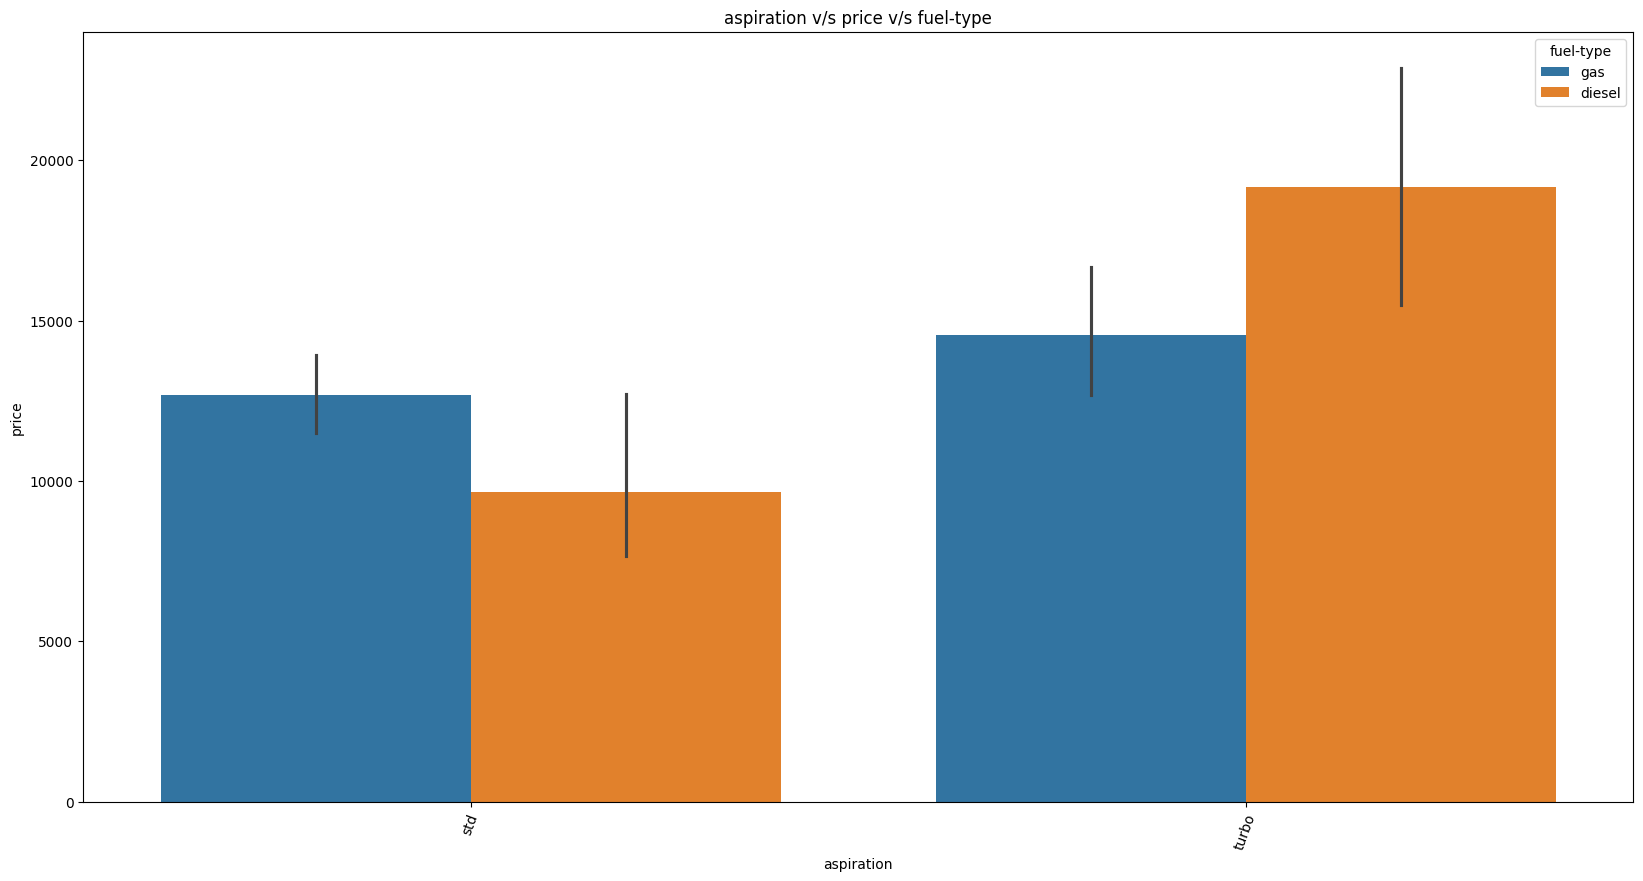

In [ ]:
# multivariate Anlaysis  of the columns aspiration,fuel-type and price
plt.figure(figsize=(20,10))
sns.barplot(data=df,x='aspiration',y='price',hue='fuel-type')
plt.title('aspiration v/s price v/s fuel-type')
plt.xticks(rotation=70)
plt.show()

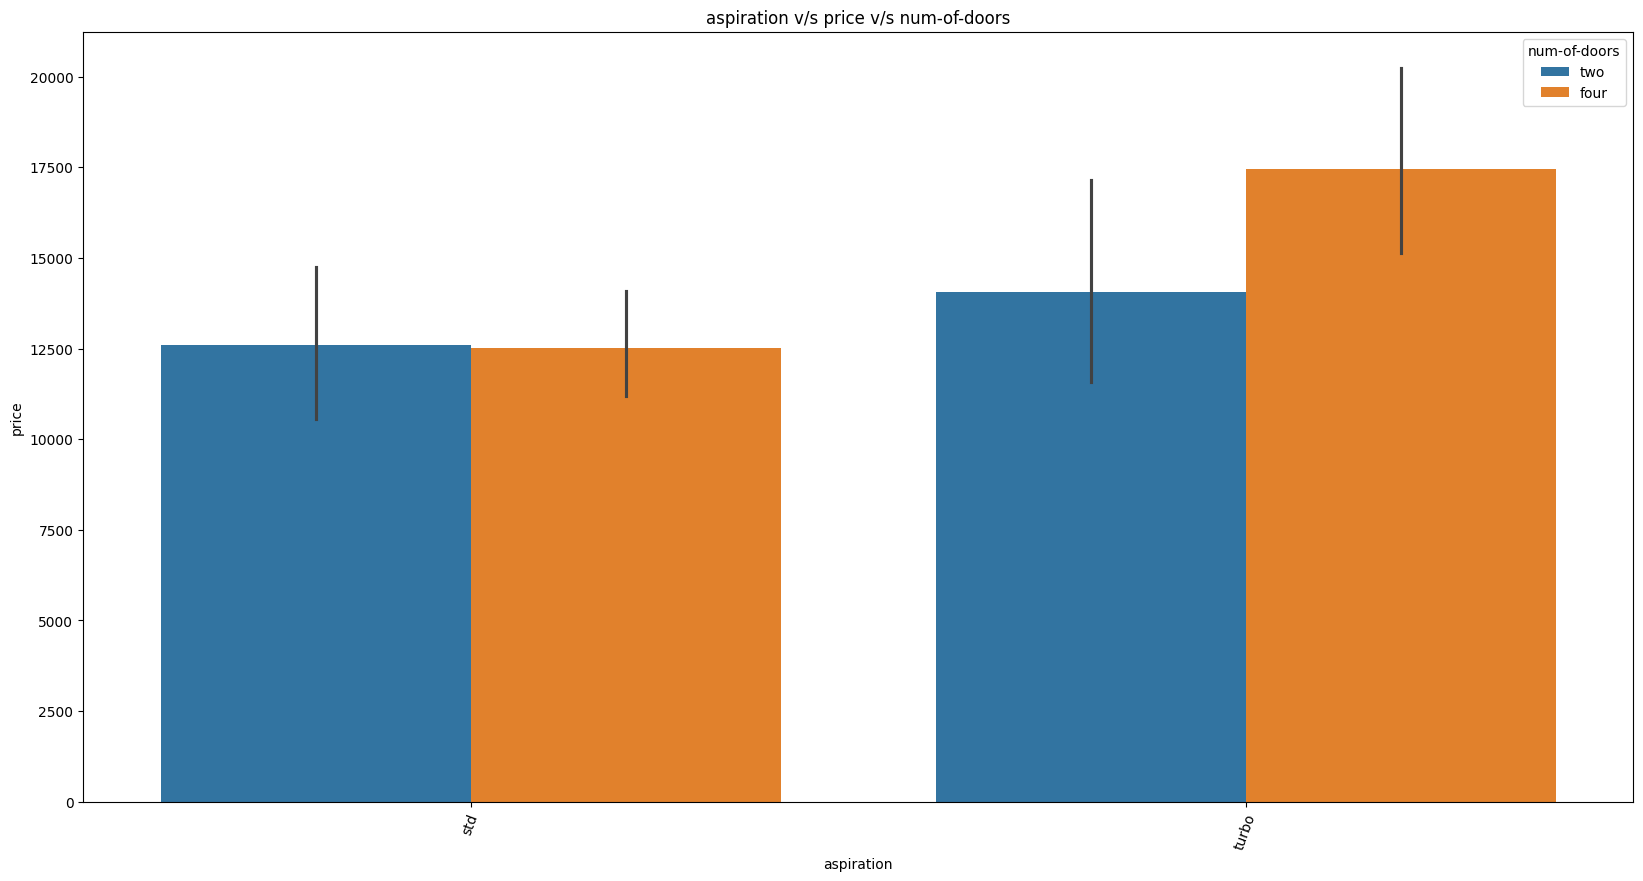

In [ ]:
# multivariate Anlaysis  of the columns aspiration,num-of-doors and price
plt.figure(figsize=(20,10))
sns.barplot(data=df,x='aspiration',y='price',hue='num-of-doors')
plt.title('aspiration v/s price v/s num-of-doors')
plt.xticks(rotation=70)
plt.show()

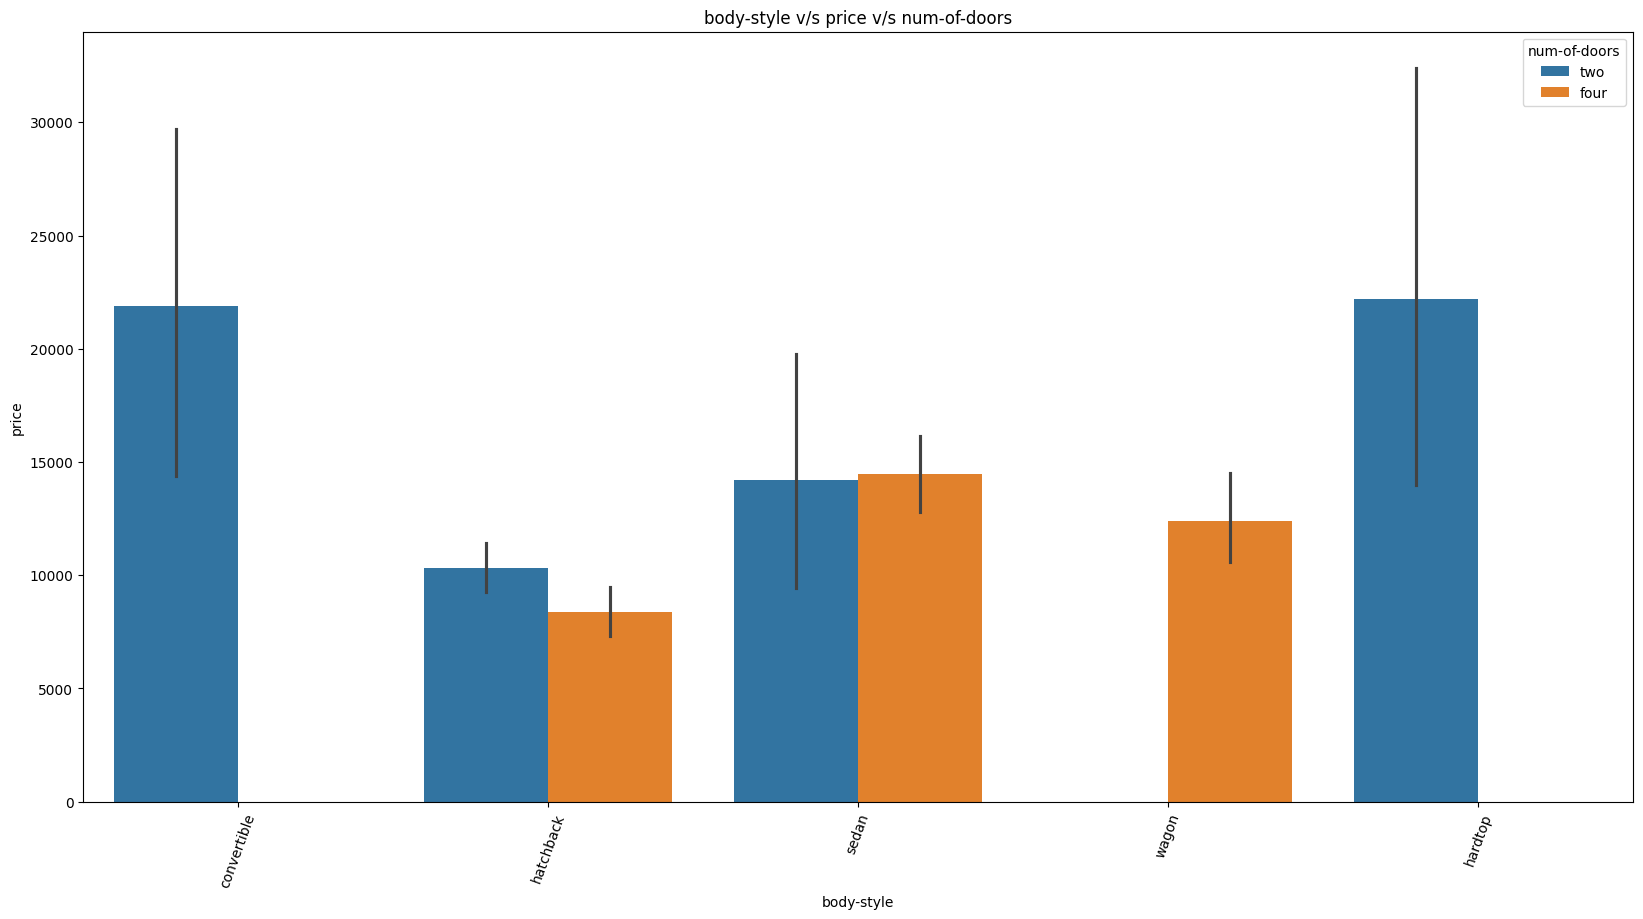

In [ ]:
# multivariate Anlaysis  of the columns body-style,num-of-doors and price
plt.figure(figsize=(20,10))
sns.barplot(data=df,x='body-style',y='price',hue='num-of-doors')
plt.title('body-style v/s price v/s num-of-doors')
plt.xticks(rotation=70)
plt.show()

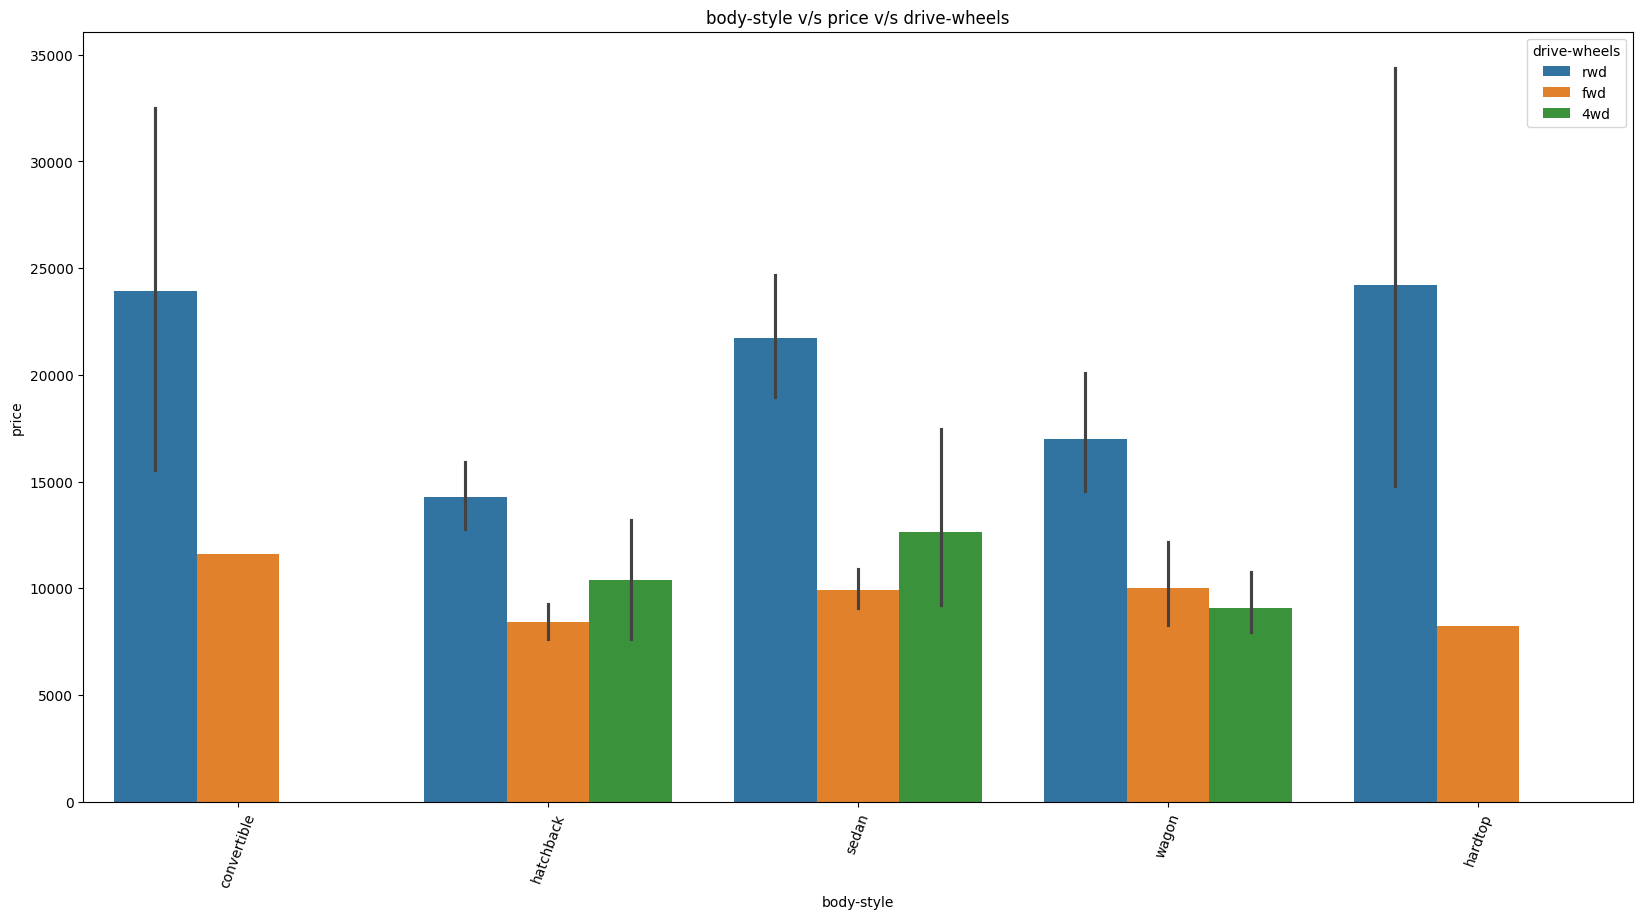

In [ ]:
# multivariate Anlaysis  of the columns body-style,drive-wheels and price
plt.figure(figsize=(20,10))
sns.barplot(data=df,x='body-style',y='price',hue='drive-wheels')
plt.title('body-style v/s price v/s drive-wheels')
plt.xticks(rotation=70)
plt.show()

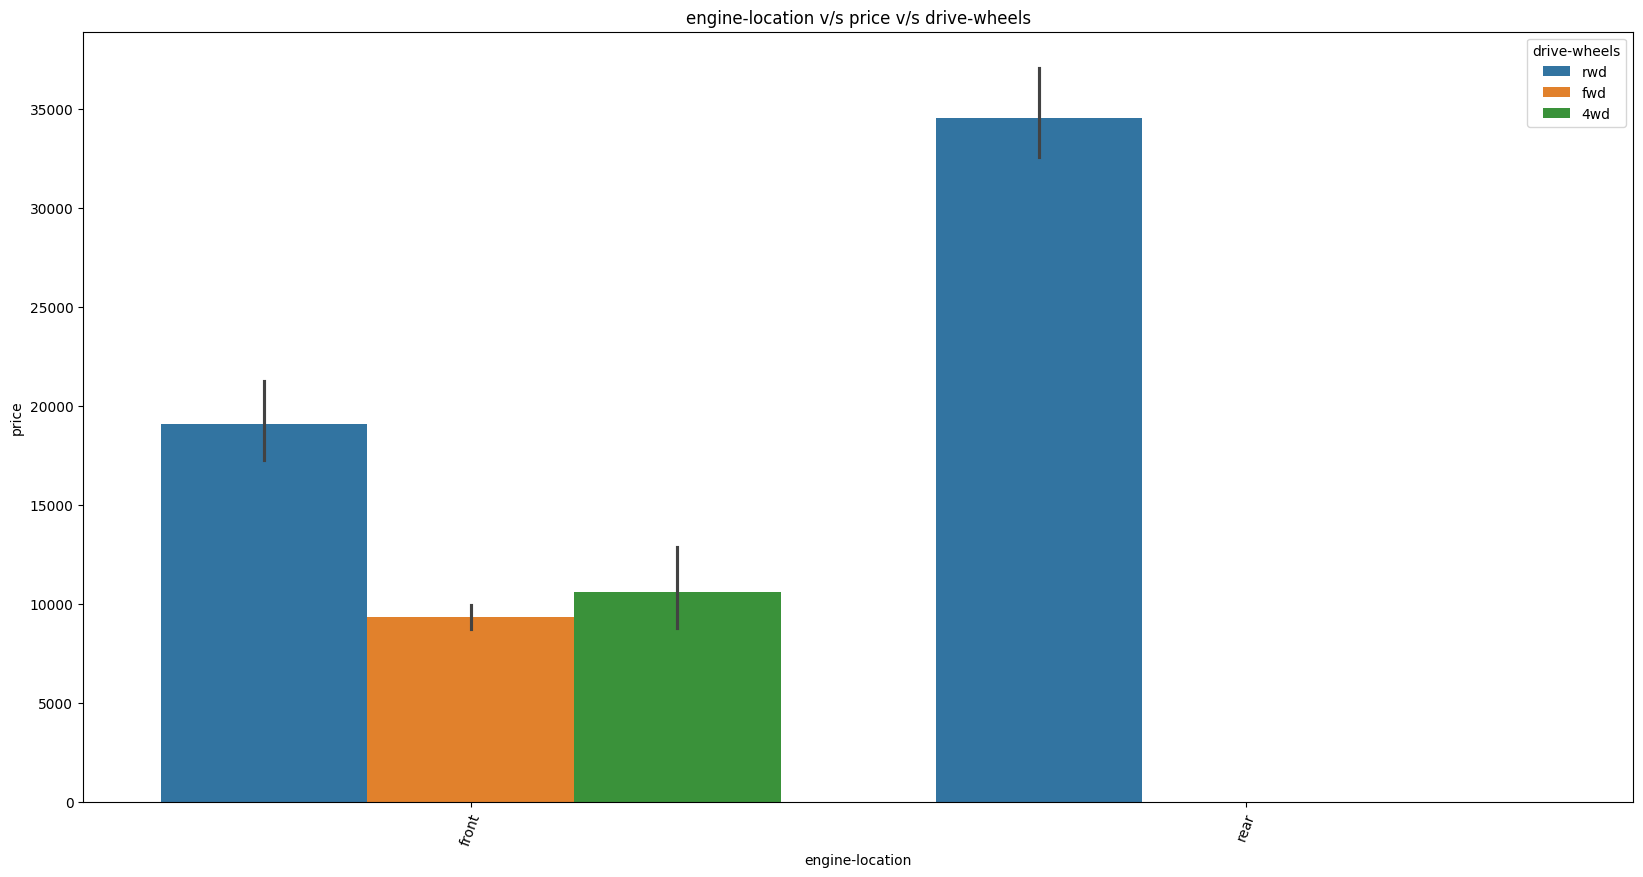

In [ ]:
# multivariate Anlaysis  of the columns engine-location,drive-wheels and price
plt.figure(figsize=(20,10))
sns.barplot(data=df,x='engine-location',y='price',hue='drive-wheels')
plt.title('engine-location v/s price v/s drive-wheels')
plt.xticks(rotation=70)
plt.show()

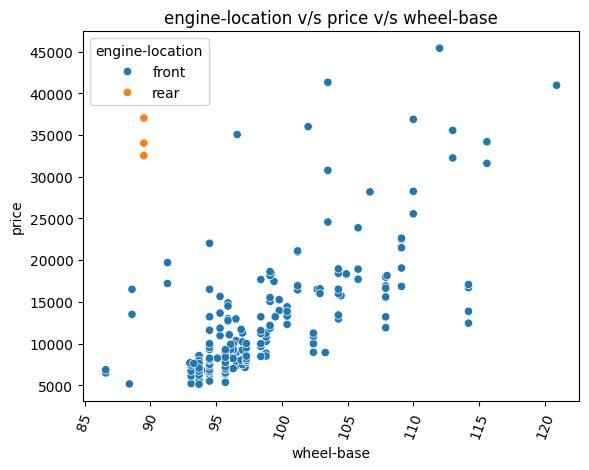

In [ ]:
# multivariate Anlaysis  of the columns engine-location,wheel-base and price
sns.scatterplot(data=df,x='wheel-base',y='price',hue='engine-location')
plt.title('engine-location v/s price v/s wheel-base')
plt.xticks(rotation=70)
plt.show()

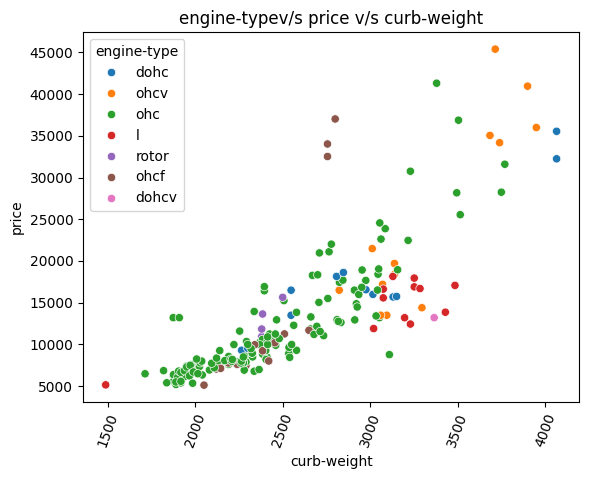

In [ ]:
# multivariate Anlaysis  of the columns curb-weight,engine-type and price

sns.scatterplot(data=df,x='curb-weight',y='price',hue='engine-type')
plt.title('engine-typev/s price v/s curb-weight')
plt.xticks(rotation=70)
plt.show()

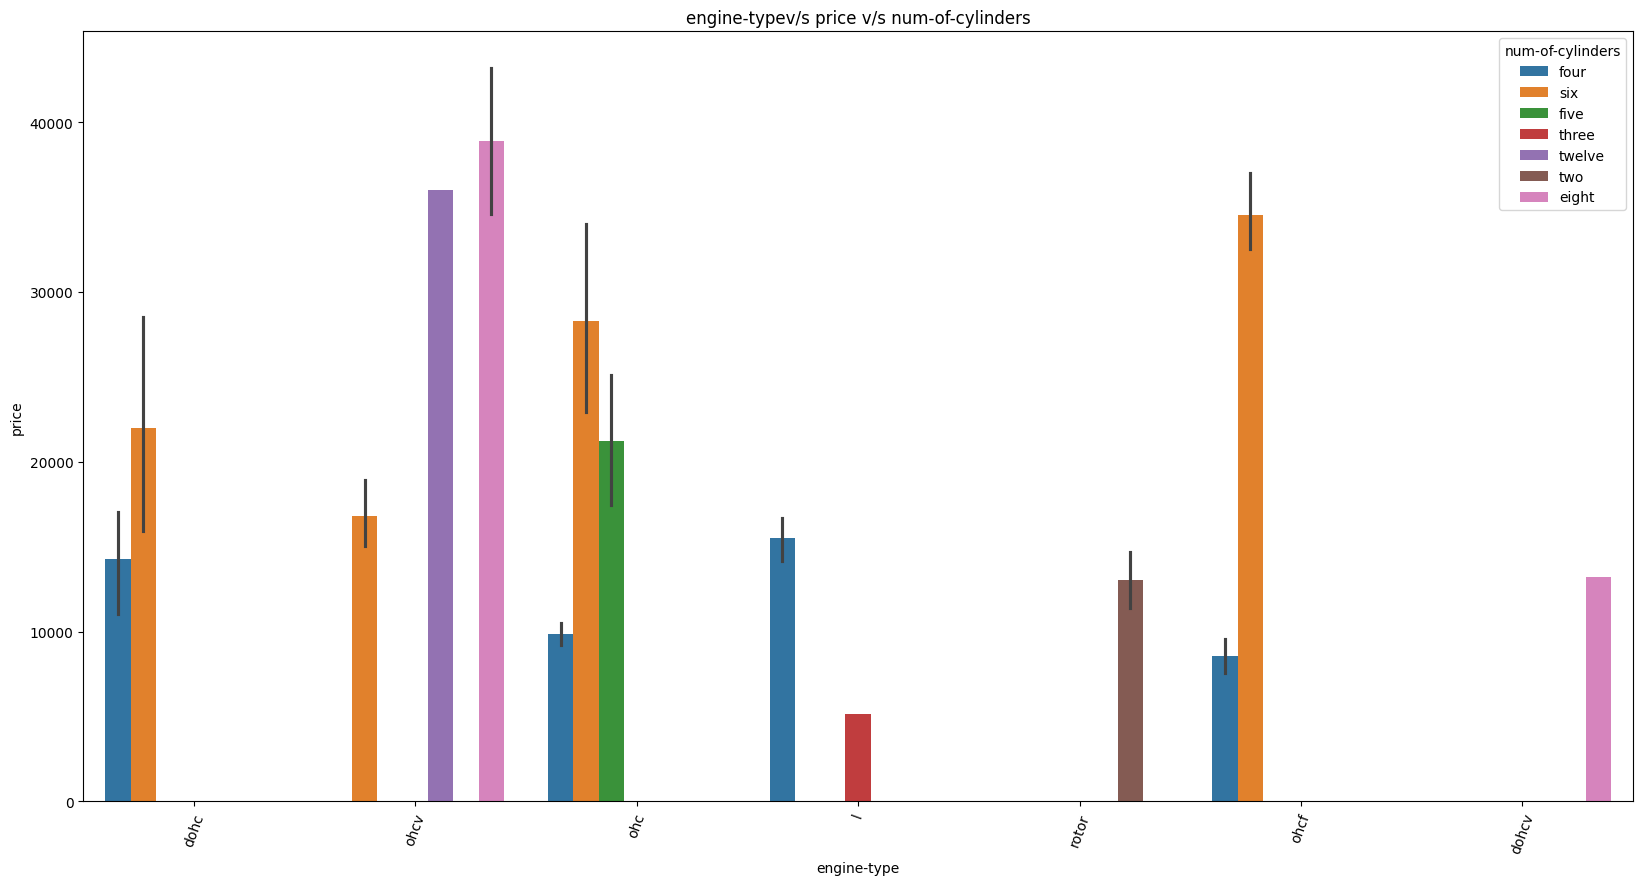

In [ ]:
# multivariate Anlaysis  of the columns num-of-cylinders,engine-type and price
plt.figure(figsize=(20,10))
sns.barplot(data=df,x='engine-type',y='price',hue='num-of-cylinders')
plt.title('engine-typev/s price v/s num-of-cylinders')
plt.xticks(rotation=70)
plt.show()

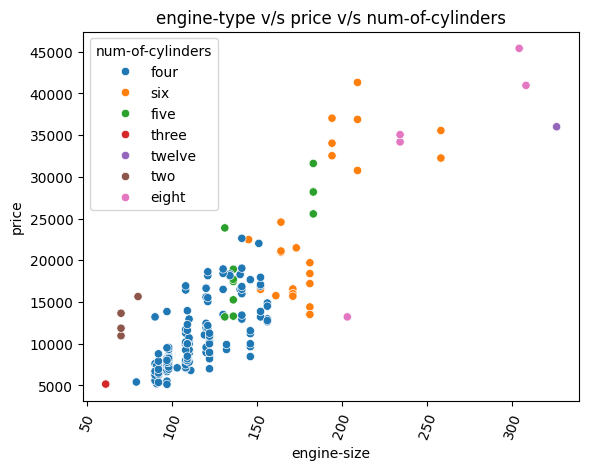

In [ ]:
# multivariate Anlaysis  of the columns num-of-cylinders,engine-size and price
sns.scatterplot(data=df,x='engine-size',y='price',hue='num-of-cylinders')
plt.title('engine-type v/s price v/s num-of-cylinders')
plt.xticks(rotation=70)
plt.show()

C:\Users\Mariya joy\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


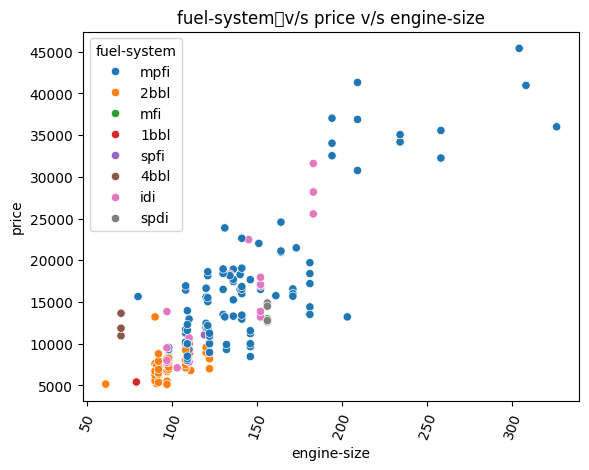

In [ ]:
# multivariate Anlaysis  of the columns fuel-system,engine-size and price
sns.scatterplot(data=df,x='engine-size',y='price',hue='fuel-system')
plt.title('fuel-system	v/s price v/s engine-size')
plt.xticks(rotation=70)
plt.show()

C:\Users\Mariya joy\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


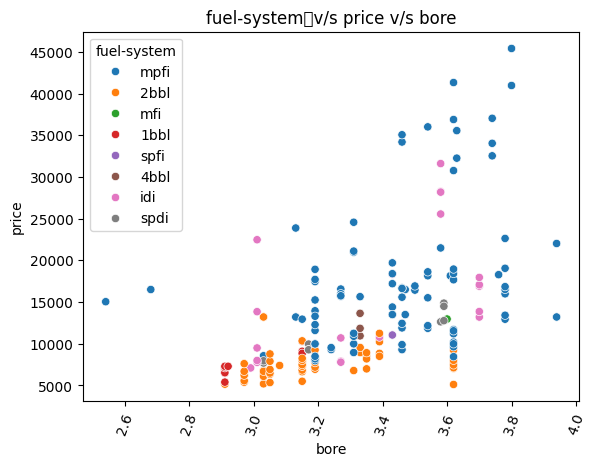

In [ ]:
# multivariate Anlaysis  of the columns fuel-system,bore and price
sns.scatterplot(data=df,x='bore',y='price',hue='fuel-system')
plt.title('fuel-system	v/s price v/s bore')
plt.xticks(rotation=70)
plt.show()

### Feature Engineering
* Data Encoding
* Data Scaling
* Feature Extraction
* Checking for Correlation
* Checking for Multicollinearity
* Feature Removal

In [ ]:
df

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,2952,ohc,four,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,188.8,68.8,55.5,3049,ohc,four,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3012,ohcv,six,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3217,ohc,six,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


##### Data Encoding - Converting categorical columns into numerical columns
* Label Encoder
* OneHot Encoder

In [ ]:
## importing required library for data encoding
from sklearn.preprocessing import LabelEncoder

In [ ]:
df['make'] = df['make'].replace({'alfa-romero':1, 'audi':1, 'bmw':2, 'chevrolet':0, 'dodge':0, 'honda':0,
       'isuzu':0, 'jaguar':3, 'mazda':0, 'mercedes-benz':3, 'mercury':1,
       'mitsubishi':0, 'nissan':0, 'peugot':1, 'plymouth':0, 'porsche':2, 'renault':0,
       'saab':1, 'subaru':0, 'toyota':0, 'volkswagen':0, 'volvo':1})
df['fuel-type']=df['fuel-type'].replace({'gas':0,'diesel':1})
lb_aspiration=LabelEncoder()
df['aspiration']=lb_aspiration.fit_transform(df['aspiration'])
df['num-of-doors']=df['num-of-doors'].replace({'four':1,'two':0})
df['body-style']=df['body-style'].replace({'convertible':2, 'hatchback':0, 'sedan':1, 'wagon':1, 'hardtop':2})
df['drive-wheels']=df['drive-wheels'].replace({'rwd':1,'fwd':0,'4wd':0})
df['engine-location']=df['engine-location'].replace({'front':0,'rear':1})
df['engine-type']=df['engine-type'].replace({'dohc':1, 'ohcv':2, 'ohc':0, 'l':0, 'rotor':0, 'ohcf':0, 'dohcv':0})
df['num-of-cylinders']=df['num-of-cylinders'].replace({'four':0, 'six':1, 'five':1, 'three':0, 'twelve':2, 'two':0, 'eight':2})
df['fuel-system']=df['fuel-system'].replace({'mpfi':3, '2bbl':0, 'mfi':1, '1bbl':0, 'spfi':1, '4bbl':1, 'idi':2, 'spdi':1})
df

C:\Users\Mariya joy\AppData\Local\Temp\ipykernel_24524\4173412034.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['make'] = df['make'].replace({'alfa-romero':1, 'audi':1, 'bmw':2, 'chevrolet':0, 'dodge':0, 'honda':0,
C:\Users\Mariya joy\AppData\Local\Temp\ipykernel_24524\4173412034.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['fuel-type']=df['fuel-type'].replace({'gas':0,'diesel':1})
C:\Users\Mariya joy\AppData\Local\Temp\ipykernel_24524\4173412034.py:8: FutureWarning: Downcasting behavior in `replace` is deprecat

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,122,1,0,0,0,2,1,0,88.6,168.8,64.1,48.8,2548,1,0,130,3,3.47,2.68,9.0,111,5000,21,27,13495
1,3,122,1,0,0,0,2,1,0,88.6,168.8,64.1,48.8,2548,1,0,130,3,3.47,2.68,9.0,111,5000,21,27,16500
2,1,122,1,0,0,0,0,1,0,94.5,171.2,65.5,52.4,2823,2,1,152,3,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,1,0,0,1,1,0,0,99.8,176.6,66.2,54.3,2337,0,0,109,3,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,1,0,0,1,1,0,0,99.4,176.6,66.4,54.3,2824,0,1,136,3,3.19,3.40,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,1,0,0,1,1,1,0,109.1,188.8,68.9,55.5,2952,0,0,141,3,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,1,0,1,1,1,1,0,109.1,188.8,68.8,55.5,3049,0,0,141,3,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,1,0,0,1,1,1,0,109.1,188.8,68.9,55.5,3012,2,1,173,3,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,1,1,1,1,1,1,0,109.1,188.8,68.9,55.5,3217,0,1,145,2,3.01,3.40,23.0,106,4800,26,27,22470


In [ ]:
df.dtypes

symboling              int64
normalized-losses      int64
make                   int64
fuel-type              int64
aspiration             int64
num-of-doors           int64
body-style             int64
drive-wheels           int64
engine-location        int64
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type            int64
num-of-cylinders       int64
engine-size            int64
fuel-system            int64
bore                 float64
stroke               float64
compression-ratio    float64
horsepower             int64
peak-rpm               int64
city-mpg               int64
highway-mpg            int64
price                  int64
dtype: object

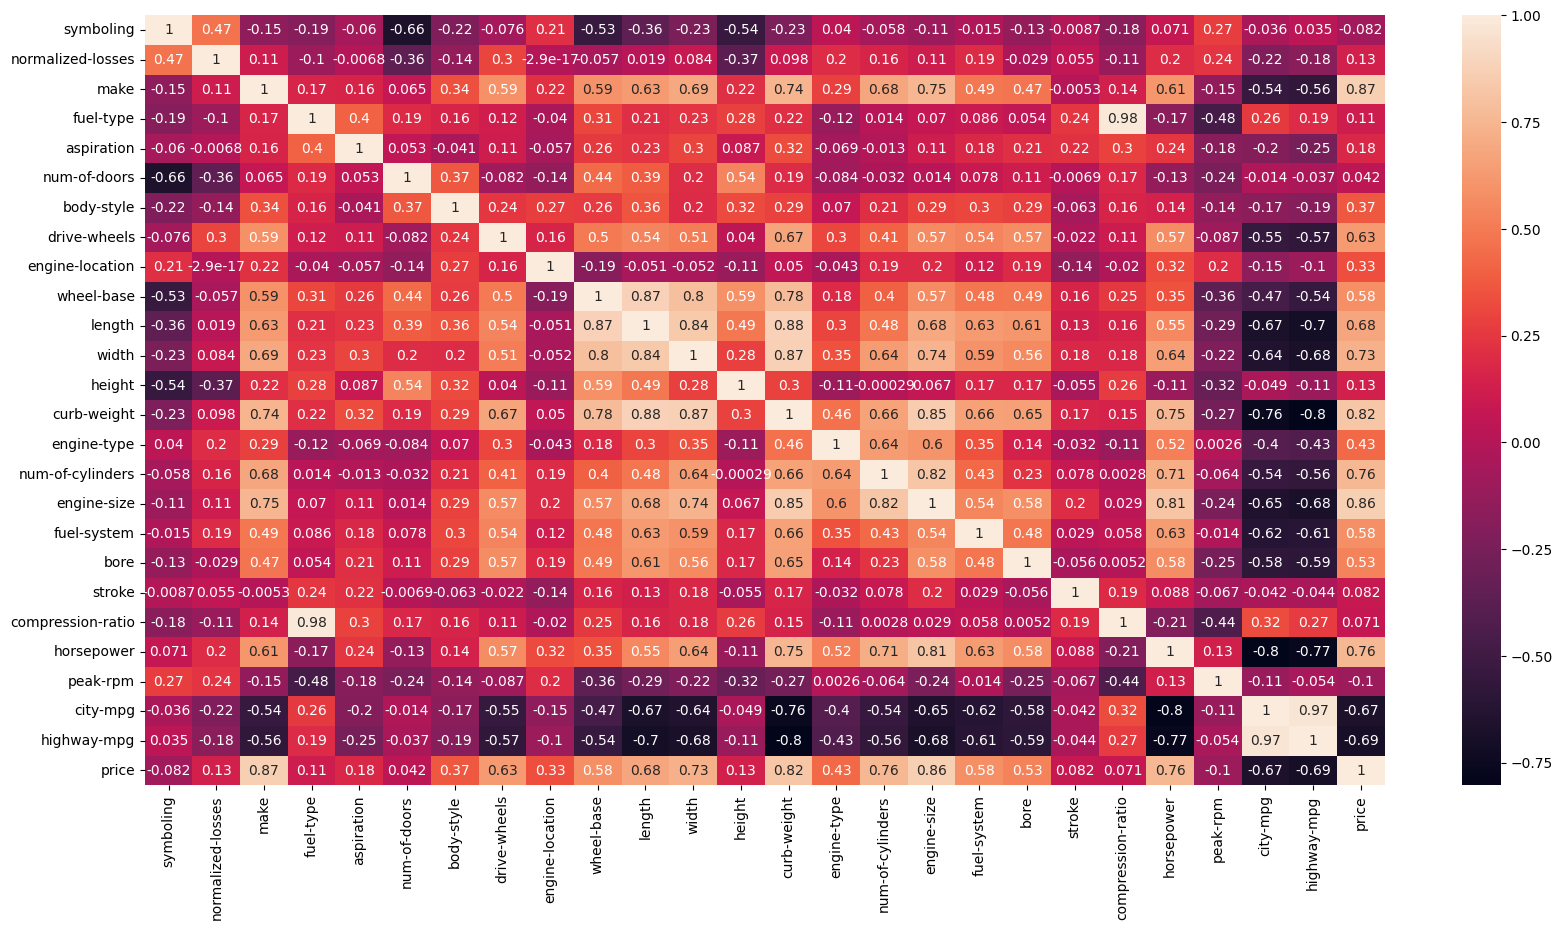

In [ ]:
# Checking for Correlation
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [ ]:
best_columns=['make','drive-wheels','wheel-base','length','width','curb-weight','num-of-cylinders','engine-size','fuel-system','bore','horsepower','price']
7=df[best_columns]
df_new

,make,drive-wheels,wheel-base,length,width,curb-weight,num-of-cylinders,engine-size,fuel-system,bore,horsepower,price
0,1,1,88.6,168.8,64.1,2548,0,130,3,3.47,111,13495
1,1,1,88.6,168.8,64.1,2548,0,130,3,3.47,111,16500
2,1,1,94.5,171.2,65.5,2823,1,152,3,2.68,154,16500
3,1,0,99.8,176.6,66.2,2337,0,109,3,3.19,102,13950
4,1,0,99.4,176.6,66.4,2824,1,136,3,3.19,115,17450
...,...,...,...,...,...,...,...,...,...,...,...,...
200,1,1,109.1,188.8,68.9,2952,0,141,3,3.78,114,16845
201,1,1,109.1,188.8,68.8,3049,0,141,3,3.78,160,19045
202,1,1,109.1,188.8,68.9,3012,1,173,3,3.58,134,21485
203,1,1,109.1,188.8,68.9,3217,1,145,2,3.01,106,22470


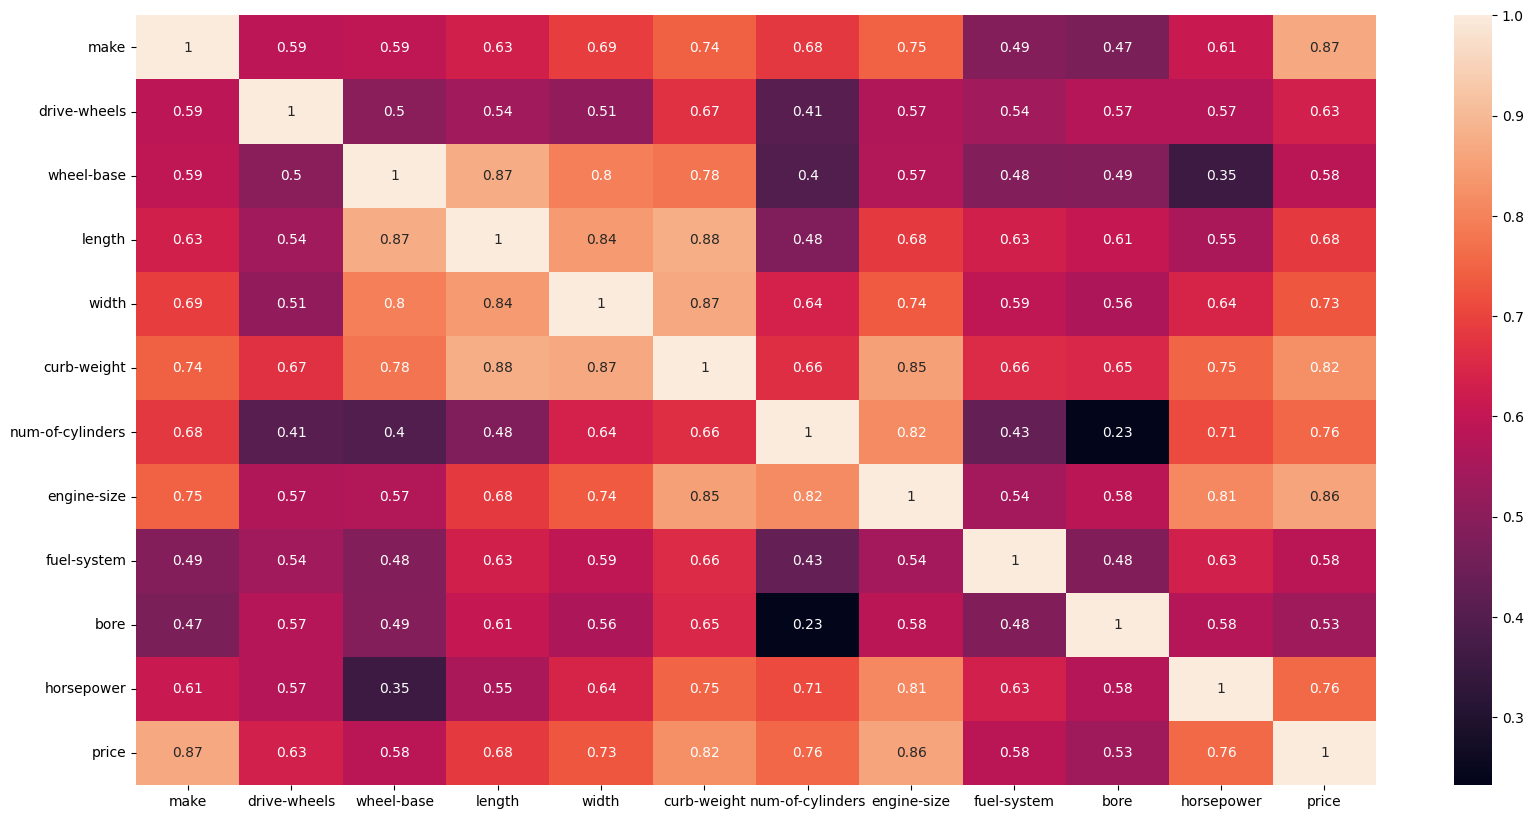

In [ ]:
# Checking for Multicollinearity
plt.figure(figsize=(20,10))
sns.heatmap(df_new.corr(),annot=True)
plt.show()

### HANDLING OUTLIERS

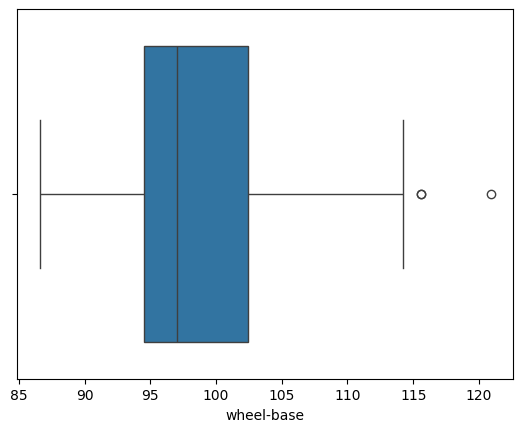

In [ ]:
sns.boxplot(df['wheel-base'],orient='h')
plt.show()

In [ ]:
q1=np.quantile(df['wheel-base'],0.25)
q3=np.quantile(df['wheel-base'],0.75)
IQR=q3-q1
minimum=q1-1.5*IQR
maximum=q3+1.5*IQR
for i in range(len(df['wheel-base'])):
    if df['wheel-base'][i]>maximum:
        df['wheel-base'][i]=maximum
    elif df['wheel-base'][i]<minimum:
        df['wheel-base'][i]=minimum
    else:
        pass

C:\Users\Mariya joy\AppData\Local\Temp\ipykernel_24524\3605387406.py:8: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['wheel-base'][i]=maximum
C:\Users\Mariya joy\AppData\Local\Temp\ipykernel_24524\3605387406.py:8: SettingWithCopyWarning:

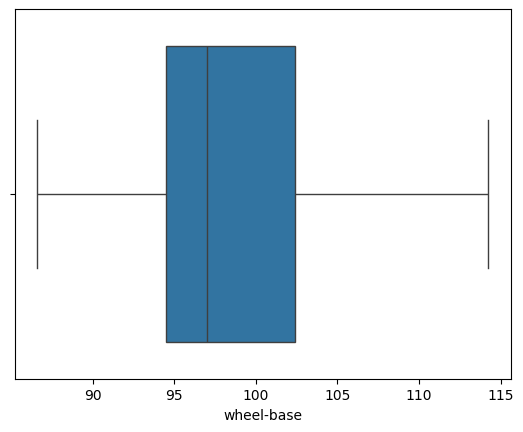

In [ ]:
sns.boxplot(df['wheel-base'],orient='h')
plt.show()

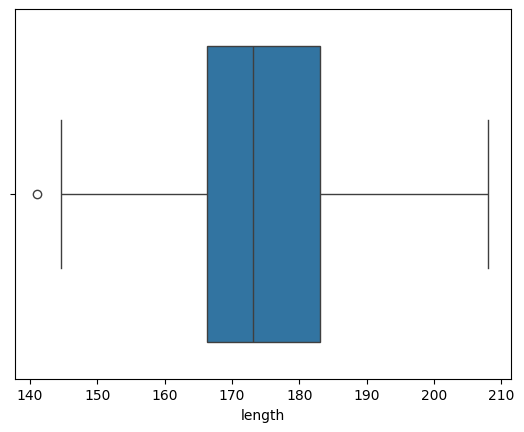

In [ ]:
sns.boxplot(df['length'],orient='h')
plt.show()

In [ ]:
q1=np.quantile(df['length'],0.25)
q3=np.quantile(df['length'],0.75)
IQR=q3-q1
minimum=q1-1.5*IQR
maximum=q3+1.5*IQR
for i in range(len(df['length'])):
    if df['length'][i]>maximum:
        df['length'][i]=maximum
    elif df['length'][i]<minimum:
        df['length'][i]=minimum
    else:
        pass

C:\Users\Mariya joy\AppData\Local\Temp\ipykernel_24524\3610953001.py:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['length'][i]=minimum
C:\Users\Mariya joy\AppData\Local\Temp\ipykernel_24524\3610953001.py:10: SettingWithCopyWarning: 


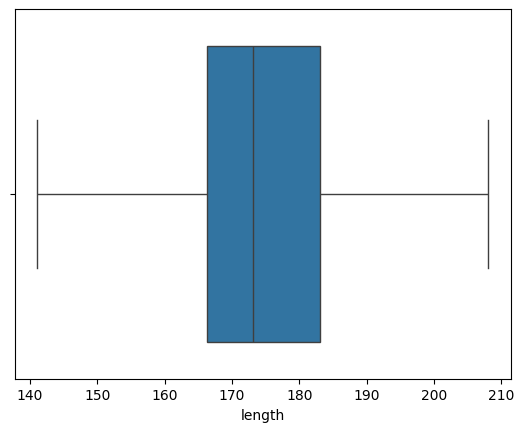

In [ ]:
sns.boxplot(df['length'],orient='h')
plt.show()

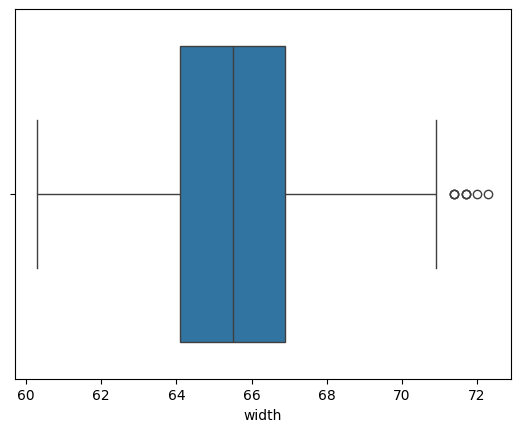

In [ ]:
sns.boxplot(df['width'],orient='h')
plt.show()

In [ ]:
q1=np.quantile(df['width'],0.25)
q3=np.quantile(df['width'],0.75)
IQR=q3-q1
minimum=q1-1.5*IQR
maximum=q3+1.5*IQR
for i in range(len(df['width'])):
    if df['width'][i]>maximum:
        df['width'][i]=maximum
    elif df['width'][i]<minimum:
        df['width'][i]=minimum
    else:
        pass

C:\Users\Mariya joy\AppData\Local\Temp\ipykernel_24524\1371401116.py:8: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['width'][i]=maximum
C:\Users\Mariya joy\AppData\Local\Temp\ipykernel_24524\1371401116.py:8: SettingWithCopyWarning: 
A v

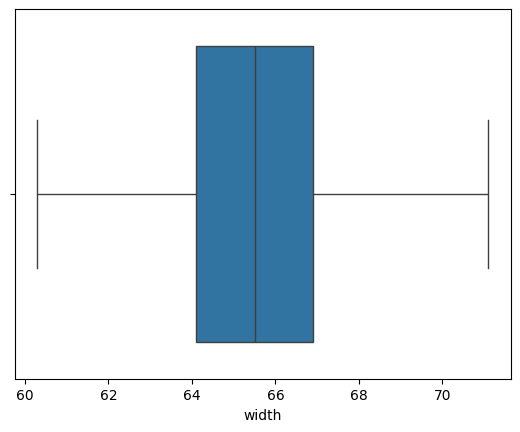

In [ ]:
sns.boxplot(df['width'],orient='h')
plt.show()

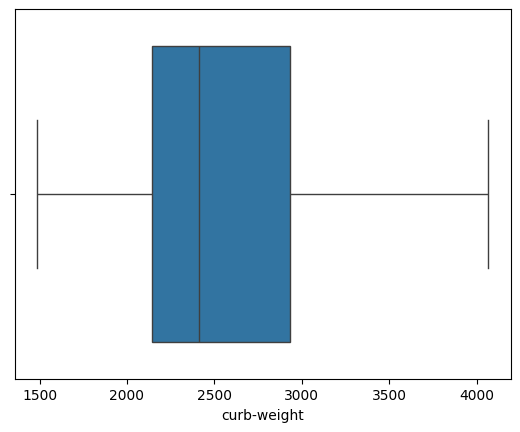

In [ ]:
sns.boxplot(df['curb-weight'],orient='h')
plt.show()

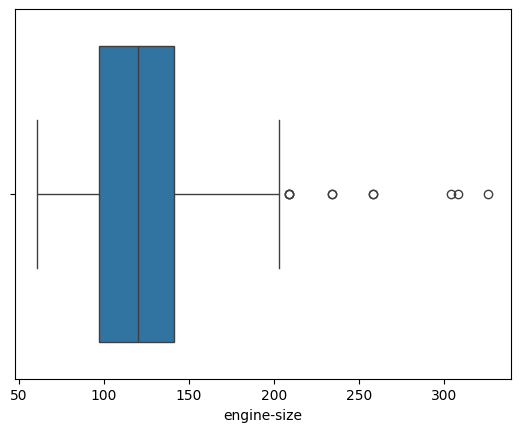

In [ ]:
sns.boxplot(df['engine-size'],orient='h')
plt.show()

In [ ]:
q1=np.quantile(df['engine-size'],0.25)
q3=np.quantile(df['engine-size'],0.75)
IQR=q3-q1
maximum=q1-1.5*IQR
minimum=q3+1.5*IQR
for i in range(len(df['engine-size'])):
    if df['engine-size'][i]<maximum:
        df['engine-size'][i]=maximum
    elif df['engine-size'][i]>minimum:
        df['engine-size'][i]=minimum
    else:
        pass

C:\Users\Mariya joy\AppData\Local\Temp\ipykernel_24524\2320902163.py:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['engine-size'][i]=minimum
C:\Users\Mariya joy\AppData\Local\Temp\ipykernel_24524\2320902163.py:10: SettingWithCopyWarni

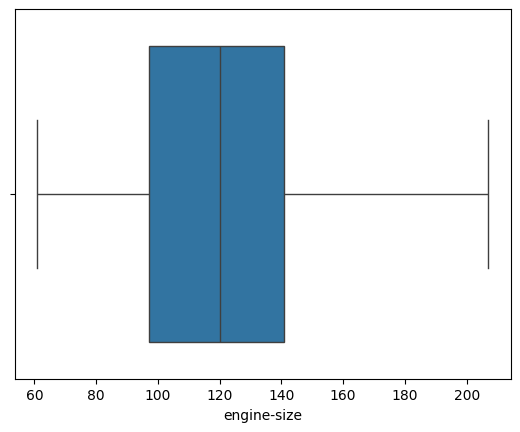

In [ ]:
sns.boxplot(df['engine-size'],orient='h')
plt.show()

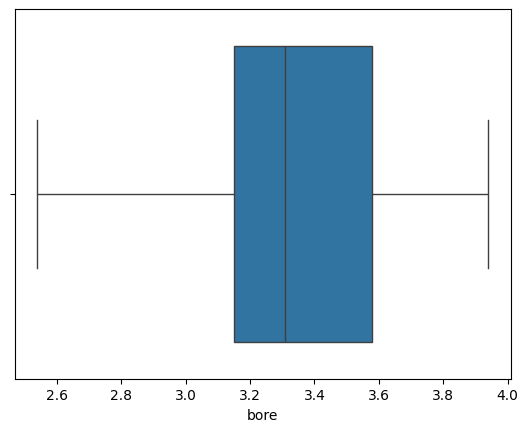

In [ ]:
sns.boxplot(df['bore'],orient='h')
plt.show()

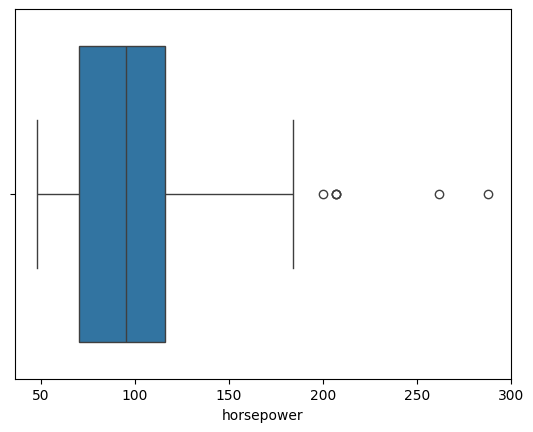

In [ ]:
sns.boxplot(df['horsepower'],orient='h')
plt.show()

In [ ]:
q1=np.quantile(df['horsepower'],0.25)
q3=np.quantile(df['horsepower'],0.75)
IQR=q3-q1
minimum=q1-1.5*IQR
maximum=q3+1.5*IQR
for i in range(len(df['horsepower'])):
    if df['horsepower'][i]>maximum:
        df['horsepower'][i]=maximum
    elif df['horsepower'][i]<minimum:
        df['horsepower'][i]=minimum
    else:
        pass

C:\Users\Mariya joy\AppData\Local\Temp\ipykernel_24524\3857474998.py:8: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['horsepower'][i]=maximum
C:\Users\Mariya joy\AppData\Local\Temp\ipykernel_24524\3857474998.py:8: SettingWithCopyWarning:

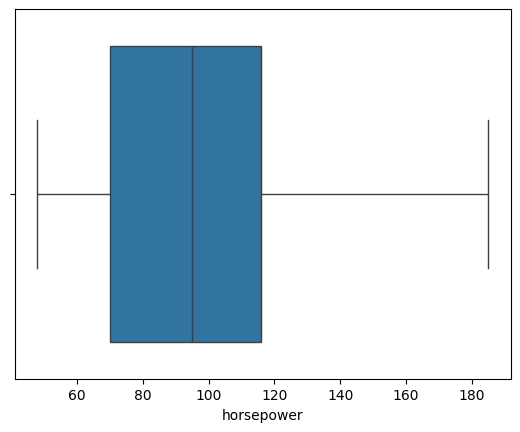

In [ ]:
sns.boxplot(df['horsepower'],orient='h')
plt.show()

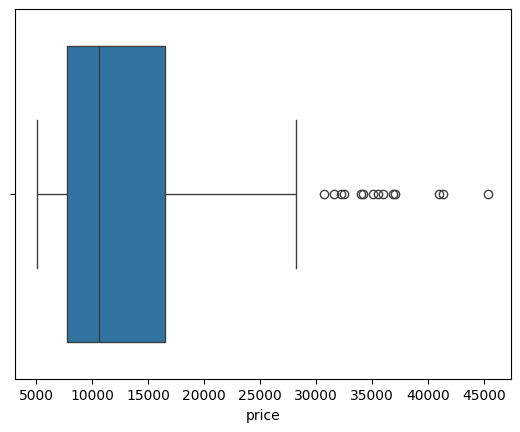

In [ ]:
sns.boxplot(df['price'],orient='h')
plt.show()

In [ ]:
q1=np.quantile(df['price'],0.25)
q3=np.quantile(df['price'],0.75)
IQR=q3-q1
minimum=q1-1.5*IQR
maximum=q3+1.5*IQR
for i in range(len(df['price'])):
    if df['price'][i]>maximum:
        df['price'][i]=maximum
    elif df['price'][i]<minimum:
        df['price'][i]=minimum
    else:
        pass

C:\Users\Mariya joy\AppData\Local\Temp\ipykernel_24524\4255602447.py:8: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['price'][i]=maximum
C:\Users\Mariya joy\AppData\Local\Temp\ipykernel_24524\4255602447.py:8: SettingWithCopyWarning: 
A v

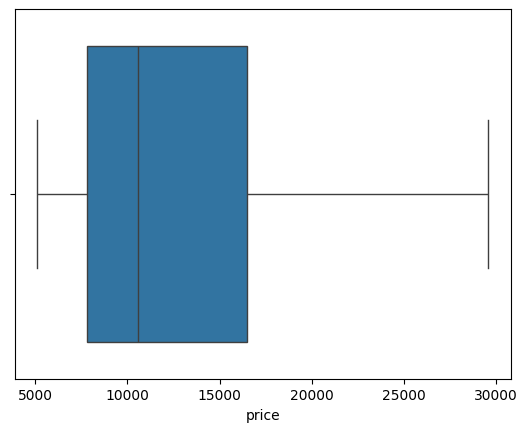

In [ ]:
sns.boxplot(df['price'],orient='h')
plt.show()

### data scaling

In [ ]:
# *Normalization (0-1)
# *Standardization (-3,+3)
df_new

,make,drive-wheels,wheel-base,length,width,curb-weight,num-of-cylinders,engine-size,fuel-system,bore,horsepower,price
0,1,1,88.6,168.8,64.1,2548,0,130,3,3.47,111,13495
1,1,1,88.6,168.8,64.1,2548,0,130,3,3.47,111,16500
2,1,1,94.5,171.2,65.5,2823,1,152,3,2.68,154,16500
3,1,0,99.8,176.6,66.2,2337,0,109,3,3.19,102,13950
4,1,0,99.4,176.6,66.4,2824,1,136,3,3.19,115,17450
...,...,...,...,...,...,...,...,...,...,...,...,...
200,1,1,109.1,188.8,68.9,2952,0,141,3,3.78,114,16845
201,1,1,109.1,188.8,68.8,3049,0,141,3,3.78,160,19045
202,1,1,109.1,188.8,68.9,3012,1,173,3,3.58,134,21485
203,1,1,109.1,188.8,68.9,3217,1,145,2,3.01,106,22470


In [ ]:
std_wheelbase=StandardScaler()
std_length=StandardScaler()
std_width=StandardScaler()
std_curbweight = StandardScaler()
std_enginesize = StandardScaler()
std_fuelsystem=StandardScaler()
std_horsepower=StandardScaler()
std_bore=StandardScaler()
df_new['wheel-base'] = std_wheelbase.fit_transform(df_new[['wheel-base']])
df_new['length'] = std_length.fit_transform(df_new[['length']])
df_new['width'] = std_width.fit_transform(df_new[['width']])
df_new['curb-weight'] = std_curbweight.fit_transform(df_new[['curb-weight']])
df_new['engine-size'] = std_enginesize.fit_transform(df_new[['engine-size']])
df_new['horsepower']=std_horsepower.fit_transform(df_new[['horsepower']])
df_new['bore']=std_bore.fit_transform(df_new[['bore']])


C:\Users\Mariya joy\AppData\Local\Temp\ipykernel_24524\1138284717.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['wheel-base'] = std_wheelbase.fit_transform(df_new[['wheel-base']])
C:\Users\Mariya joy\AppData\Local\Temp\ipykernel_24524\1138284717.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['length'] = std_length.fit_transform(df_new[['length']])
C:\Users\Mariya joy\AppData\Local\Temp\ipykernel_24524\1138284717.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy 

### MODEL BUILDING

In [ ]:
df_new

,make,drive-wheels,wheel-base,length,width,curb-weight,num-of-cylinders,engine-size,fuel-system,bore,horsepower,price
0,1,1,-1.690772,-0.426521,-0.844782,-0.014566,0,0.074449,3,0.519089,0.171128,13495
1,1,1,-1.690772,-0.426521,-0.844782,-0.014566,0,0.074449,3,0.519089,0.171128,16500
2,1,1,-0.708596,-0.231513,-0.190566,0.514882,1,0.604046,3,-2.404862,1.261870,16500
3,1,0,0.173698,0.207256,0.136542,-0.420797,0,-0.431076,3,-0.517248,-0.057167,13950
4,1,0,0.107110,0.207256,0.230001,0.516807,1,0.218885,3,-0.517248,0.272593,17450
...,...,...,...,...,...,...,...,...,...,...,...,...
200,1,1,1.721873,1.198549,1.398245,0.763241,0,0.339248,3,1.666463,0.247227,16845
201,1,1,1.721873,1.198549,1.351515,0.949992,0,0.339248,3,1.666463,1.414067,19045
202,1,1,1.721873,1.198549,1.398245,0.878757,1,1.109571,3,0.926222,0.754548,21485
203,1,1,1.721873,1.198549,1.398245,1.273437,1,0.435538,2,-1.183465,0.044298,22470


In [ ]:
# splitting the dataset into input features and target varibles

x = df_new.drop('price',axis=1)
y = df_new['price']

In [ ]:
x

,make,drive-wheels,wheel-base,length,width,curb-weight,num-of-cylinders,engine-size,fuel-system,bore,horsepower
0,1,1,-1.690772,-0.426521,-0.844782,-0.014566,0,0.074449,3,0.519089,0.171128
1,1,1,-1.690772,-0.426521,-0.844782,-0.014566,0,0.074449,3,0.519089,0.171128
2,1,1,-0.708596,-0.231513,-0.190566,0.514882,1,0.604046,3,-2.404862,1.261870
3,1,0,0.173698,0.207256,0.136542,-0.420797,0,-0.431076,3,-0.517248,-0.057167
4,1,0,0.107110,0.207256,0.230001,0.516807,1,0.218885,3,-0.517248,0.272593
...,...,...,...,...,...,...,...,...,...,...,...
200,1,1,1.721873,1.198549,1.398245,0.763241,0,0.339248,3,1.666463,0.247227
201,1,1,1.721873,1.198549,1.351515,0.949992,0,0.339248,3,1.666463,1.414067
202,1,1,1.721873,1.198549,1.398245,0.878757,1,1.109571,3,0.926222,0.754548
203,1,1,1.721873,1.198549,1.398245,1.273437,1,0.435538,2,-1.183465,0.044298


In [ ]:
y

0      13495
1      16500
2      16500
3      13950
4      17450
       ...  
200    16845
201    19045
202    21485
203    22470
204    22625
Name: price, Length: 205, dtype: int64

In [ ]:
# splitting into train and test data
# train data - 80%
# test data - 20%

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
x_train

,make,drive-wheels,wheel-base,length,width,curb-weight,num-of-cylinders,engine-size,fuel-system,bore,horsepower
66,0,1,1.022697,0.077250,0.089812,0.278074,0,0.170739,2,0.371041,-0.818149
111,1,1,1.522109,1.027916,1.164596,1.000049,0,-0.166277,3,0.482077,-0.234729
153,0,0,-0.508831,-0.353393,-1.078431,-0.530538,0,-0.840310,0,-1.035417,-1.071810
96,0,0,-0.708596,-0.710909,-0.984972,-1.125445,0,-0.719947,0,-0.665296,-0.894247
38,0,0,-0.375655,-0.532151,-0.330755,-0.513210,0,-0.407003,0,-0.665296,-0.463024
...,...,...,...,...,...,...,...,...,...,...,...
106,0,1,0.073815,0.361638,0.930947,1.123266,1,1.302152,3,0.371041,1.414067
14,2,1,0.789639,1.214799,0.463650,0.961544,1,0.892917,3,-0.073103,0.424789
92,0,0,-0.708596,-0.710909,-0.984972,-1.188979,0,-0.719947,0,-0.665296,-0.894247
179,0,1,0.689756,0.767905,0.837488,0.886458,1,1.061426,3,-0.221152,1.439433


In [ ]:
x_test

,make,drive-wheels,wheel-base,length,width,curb-weight,num-of-cylinders,engine-size,fuel-system,bore,horsepower
15,2,1,0.789639,1.214799,0.463650,1.298465,1,1.976184,3,1.074270,1.972121
9,1,0,0.123757,0.337262,0.930947,0.957693,1,0.098522,3,-0.739320,1.414067
100,0,0,-0.259126,-0.052755,-0.330755,-0.488182,0,-0.166277,0,0.000921,-0.183997
132,1,0,0.057168,1.019791,0.276731,0.197213,0,-0.142204,3,0.778174,0.145762
68,3,1,1.871697,1.369181,2.052461,2.299604,1,1.350297,2,0.926222,0.475521
95,0,0,-0.708596,-0.686533,-0.984972,-1.015705,0,-0.719947,0,-0.665296,-0.894247
159,0,0,-0.508831,-0.629655,-0.704593,-0.540164,0,-0.407003,2,-0.221152,-1.224007
162,0,0,-0.508831,-0.629655,-0.704593,-0.800075,0,-0.695874,0,-0.517248,-0.868881
147,0,0,-0.292420,-0.044630,-0.237296,-0.193616,0,-0.455148,3,1.074270,-0.260095
182,0,0,-0.242478,-0.190886,-0.190566,-0.567118,0,-0.719947,2,-1.183465,-1.325471


In [ ]:
y_train

66     18344
111    15580
153     6918
96      7499
38      9095
       ...  
106    18399
14     24565
92      6849
179    15998
102    14399
Name: price, Length: 164, dtype: int64

In [ ]:
y_test

15     30760
9      13207
100     9549
132    11850
68     28248
95      7799
159     7788
162     9258
147    10198
182     7775
191    13295
164     8238
65     18280
175     9988
73     40960
152     6488
18      5151
82     12629
86      8189
143     9960
60      8495
101    13499
98      8249
30      6479
25      6692
16     41315
168     9639
195    13415
97      7999
194    12940
67     25552
120     6229
154     7898
202    21485
79      7689
69     28176
145    11259
55     10945
45     13207
84     14489
146     7463
Name: price, dtype: int64

In [ ]:
# creating the object the class KNeighborRegressor

knn = KNeighborsRegressor(n_neighbors=7)  # knn algorithms (selecting 7 neighbors of the data)

In [ ]:
# Training the model
knn.fit(x_train,y_train)

KNeighborsRegressor(n_neighbors=7)

In [ ]:
y_predknn = knn.predict(x_test)
y_predknn

array([21159.42857143, 16503.57142857,  8995.28571429, 13619.14285714,
       29330.57142857,  6868.85714286,  8451.        ,  7482.71428571,
       10295.71428571,  9003.14285714, 12197.        ,  7591.14285714,
       13050.71428571, 10367.42857143, 35980.57142857,  7371.57142857,
        7398.71428571, 11451.71428571,  9338.14285714,  9881.14285714,
        9338.14285714, 15756.14285714,  6924.42857143,  6204.71428571,
        6316.71428571, 24037.14285714, 11492.        , 18212.85714286,
        6868.85714286, 18212.85714286, 25039.85714286,  6316.71428571,
        7408.85714286, 17480.71428571,  6843.71428571, 25164.42857143,
       10295.71428571, 10444.71428571,  7118.14285714, 11451.71428571,
        8318.57142857])

In [ ]:
accuracy = knn.score(x_test,y_test)
accuracy

0.8084224387739494

In [ ]:
r2_score(y_test,y_predknn)

0.8084224387739494

In [ ]:
mean_squared_error(y_test,y_predknn)

np.float64(14937700.765555002)

In [ ]:
mean_absolute_error(y_test,y_predknn)

np.float64(2308.975609756097)

In [ ]:
df_new

,make,drive-wheels,wheel-base,length,width,curb-weight,num-of-cylinders,engine-size,fuel-system,bore,horsepower,price
0,1,1,-1.690772,-0.426521,-0.844782,-0.014566,0,0.074449,3,0.519089,0.171128,13495
1,1,1,-1.690772,-0.426521,-0.844782,-0.014566,0,0.074449,3,0.519089,0.171128,16500
2,1,1,-0.708596,-0.231513,-0.190566,0.514882,1,0.604046,3,-2.404862,1.261870,16500
3,1,0,0.173698,0.207256,0.136542,-0.420797,0,-0.431076,3,-0.517248,-0.057167,13950
4,1,0,0.107110,0.207256,0.230001,0.516807,1,0.218885,3,-0.517248,0.272593,17450
...,...,...,...,...,...,...,...,...,...,...,...,...
200,1,1,1.721873,1.198549,1.398245,0.763241,0,0.339248,3,1.666463,0.247227,16845
201,1,1,1.721873,1.198549,1.351515,0.949992,0,0.339248,3,1.666463,1.414067,19045
202,1,1,1.721873,1.198549,1.398245,0.878757,1,1.109571,3,0.926222,0.754548,21485
203,1,1,1.721873,1.198549,1.398245,1.273437,1,0.435538,2,-1.183465,0.044298,22470


In [ ]:
knn.predict([[1,1,1.721873,1.198549,1.398245,0.763241,0,0.339248,3,1.666463,0.247227]])

C:\Users\Mariya joy\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


array([17480.71428571])

In [ ]:
knn.predict([[1,1,-1.690772,-0.426521,-0.844782,-0.014566,0,0.074449,3,0.519089,0.171128]])

C:\Users\Mariya joy\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


array([11844.85714286])

In [ ]:
#  def automobile_price_predictor(make,drive_wheels,wheel_base,length,width,curb_weight,num_of_cylinders,engine_size,fuel_system,bore,horsepower):
#     wheel_base_scale = std_wheelbase.transform([[wheel_base]])[0,0]
#     length_scale = std_length.transform([[length]])[0,0]
#     width_scale = std_width.transform([[width]])[0,0]
#     curb_weight_scale = std_curbweight.transform([[curb_weight]])[0,0]
#     enginesize_scale = std_enginesize.transform([[engine_size]])[0,0]
#     bore_scale = std_bore.transform([[bore]])[0,0]
#     horsepower_scale = std_horsepower.transform([[horsepower]])[0,0]
#     price = knn.predict([[make,drive_wheels,wheel_base_scale,length_scale,width_scale,curb_weight_scale,num_of_cylinders,enginesize_scale,fuel_system,bore_scale,horsepower_scale]])
#     return pricek
# make =int(input(" select your brand name:\n 1.alfa-romero\n 2.audi\n 3.bmw\n 4.chevrolet\n 5.dodge\n 6.honda\n 7.isuzu\n 8.jaguar\n 9mazda\n 10.mercedes-benz\n 11.mercury\n 12.mitsubishi\n 13.nissan\n 14.peugot\n 15.plymouth\n 16.porsche\n 17.renault\n 18.saab\n 19.subaru\n 20.toyota\n 21.volkswagen\n 22.volvo"))
# drive_wheels=int(input("select drive wheels:\n 1.rwd\n2.fwd\n3.4wd"))
# wheel_base_scale= float(input('Enter wheelbase : '))
# length = float(input("Enter length: "))
# width = float(input("Enter width: "))
# curb_weight =int(input("Enter curb-weigth: "))
# num_of_cylinders=int(input("select num of cylinders:\n1.four\n2.six\n3.five\n4.three\n5.twelve\n6.two\n7.eight"))
# engine_size= int(input("Enter engine-size: "))
# fuel_system=int(input("select fuelsystem:\n1.mpfi\n2.2bbl\n3.mfi'\n4.1bbl\n5.spfi\n6.4bbl\n7.idi\n8.spdi"))
# bore = float(input("Enter bore: "))
# horsepower = int(input("Enter horsepower: "))
# price_ = automobile_price_predictor(make,drive_wheels,wheel_base,length,width,curb_weight,num_of_cylinders,engine_size,fuel_system,bore,horsepower)[0]
# print(f"The Eligible  price as per your history is {price_}")


In [ ]:
df['drive-wheels'].unique()

array([1, 0])

In [ ]:
df_new

,make,drive-wheels,wheel-base,length,width,curb-weight,num-of-cylinders,engine-size,fuel-system,bore,horsepower,price
0,1,1,-1.690772,-0.426521,-0.844782,-0.014566,0,0.074449,3,0.519089,0.171128,13495
1,1,1,-1.690772,-0.426521,-0.844782,-0.014566,0,0.074449,3,0.519089,0.171128,16500
2,1,1,-0.708596,-0.231513,-0.190566,0.514882,1,0.604046,3,-2.404862,1.261870,16500
3,1,0,0.173698,0.207256,0.136542,-0.420797,0,-0.431076,3,-0.517248,-0.057167,13950
4,1,0,0.107110,0.207256,0.230001,0.516807,1,0.218885,3,-0.517248,0.272593,17450
...,...,...,...,...,...,...,...,...,...,...,...,...
200,1,1,1.721873,1.198549,1.398245,0.763241,0,0.339248,3,1.666463,0.247227,16845
201,1,1,1.721873,1.198549,1.351515,0.949992,0,0.339248,3,1.666463,1.414067,19045
202,1,1,1.721873,1.198549,1.398245,0.878757,1,1.109571,3,0.926222,0.754548,21485
203,1,1,1.721873,1.198549,1.398245,1.273437,1,0.435538,2,-1.183465,0.044298,22470


In [ ]:
decision_tree=DecisionTreeRegressor()

In [ ]:
# tranining the moedel
decision_tree.fit(x_train,y_train)

DecisionTreeRegressor()

In [ ]:
y_pred_decision=decision_tree.predict(x_test)
y_pred_decision

array([36880. , 15998. ,  9538. , 12170. , 31600. ,  7499. ,  7898. ,
        8358. , 11694. ,  7995. , 11199. ,  8058. , 11199. , 10898. ,
       36000. ,  6338. ,  5974.5, 12764. ,  9279. ,  8948. , 10245. ,
       15690. ,  7499. ,  5974.5,  7609. , 36880. ,  8449. , 16515. ,
        7349. , 15985. , 31600. ,  6229. ,  6918. , 18920. ,  7957. ,
       31600. , 11694. , 11845. ,  9751. , 14869. ,  7775. ])

In [ ]:
accuaracy=decision_tree.score(x_test,y_test)
accuaracy

0.9181329229944627

In [ ]:
r2_score(y_test,y_pred_decision)

0.9181329229944627

In [ ]:
mean_squared_error(y_test,y_pred_decision)

np.float64(6383346.207317073)

In [ ]:
mean_absolute_error(y_test,y_pred_decision)

np.float64(1740.439024390244)

In [ ]:
linear=LinearRegression()

In [ ]:
linear.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pred_linear=linear.predict(x_test)
y_pred_linear

array([27332.45054629, 18332.41146076,  9284.42027795, 15805.97821584,
       30179.40381287,  7334.72457517,  8669.40867327,  7502.00691671,
        9563.82709556,  8486.49433806, 12661.86040821,  8817.7953409 ,
       11603.33023707,  9979.19618127, 37383.18952205,  6522.18410241,
        3699.50426854, 12873.75350026,  9554.12942032,  9246.88832038,
        9564.76871808, 15835.04946009,  7036.66380169,  6724.75685135,
        6785.81987441, 28014.49535533, 12719.13711397, 17634.63541336,
        7600.04260937, 17416.03703435, 29758.33316478,  6746.40049459,
        7610.82008213, 19763.53983674,  8157.93066832, 30027.11941354,
        9768.38395445,  8410.85867989,  6371.93894194, 13029.12674748,
        8254.54131447])

In [ ]:
accuaracy=linear.score(x_test,y_test)
accuaracy

0.8622381927078926

In [ ]:
r2_score(y_test,y_pred_linear)

0.8622381927078926

In [ ]:
mean_squared_error(y_test,y_pred_linear)

np.float64(10741574.54078567)

In [ ]:
mean_absolute_error(y_test,y_pred_linear)

np.float64(2122.7517079946565)

### Model Building using RandomForest Regressor (Bagging Method)

In [ ]:
random=RandomForestRegressor()

In [ ]:
random.fit(x_train,y_train)

RandomForestRegressor()

In [ ]:
y_pred_random=random.predict(x_test)
y_pred_random

array([33504.79714286, 18247.88      ,  9178.38      , 13049.805     ,
       29458.55      ,  7329.23      ,  7972.96      ,  7926.52      ,
       10244.35      ,  8069.57      , 12235.37      ,  7971.44      ,
       12719.01      , 10679.12      , 38638.65      ,  6405.58      ,
        6343.46683333, 13728.62      ,  8420.04      ,  9431.9       ,
       10399.89      , 14346.29      ,  7311.64      ,  5984.9375    ,
        7030.87      , 33088.55714286,  9540.66      , 16562.63      ,
        7316.21      , 16215.9       , 29312.55      ,  6448.1       ,
        7974.97      , 19533.2       ,  8110.84      , 28798.0375    ,
       10258.44      , 12009.62333333,  8100.96      , 14545.09      ,
        8432.7       ])

In [ ]:
accuaracy=random.score(x_test,y_test)
accuaracy

0.9308221773797036

In [ ]:
r2_score(y_test,y_pred_random)

0.9308221773797036

In [ ]:
mean_squared_error(y_test,y_pred_random)

np.float64(5393938.660150947)

In [ ]:
mean_absolute_error(y_test,y_pred_random)

np.float64(1490.9747601626018)

### Model Building using AdaBoost Regressor (Bagging Method)

In [ ]:
ada=AdaBoostRegressor()

In [ ]:
ada.fit(x_train,y_train)

AdaBoostRegressor()

In [ ]:
y_pred_ada=ada.predict(x_test)
y_pred_ada

array([34224.2       , 17701.375     ,  9611.28571429, 14909.75757576,
       34543.84615385,  8710.22222222,  9148.44827586,  9589.45454545,
       10064.15555556,  9148.44827586, 14593.25373134,  9589.45454545,
       14518.5       , 11165.47058824, 37838.76923077,  8710.22222222,
        8590.46153846, 14948.73770492,  9611.28571429,  9955.325     ,
        9865.87037037, 15824.34782609,  8710.22222222,  8366.61403509,
        8366.61403509, 34310.81818182, 11844.        , 16946.80327869,
        8710.22222222, 16946.80327869, 34543.84615385,  8366.61403509,
        8850.28571429, 20831.96969697,  9611.28571429, 33900.5       ,
       10610.4       , 10610.4       ,  9589.45454545, 14948.73770492,
        9611.28571429])

In [ ]:
accuaracy=ada.score(x_test,y_test)
accuaracy  j

0.8819625483438385

In [ ]:
r2_score(y_test,y_pred_ada)

0.8819625483438385

In [ ]:
mean_squared_error(y_test,y_pred_ada)

np.float64(9203625.522134716)

In [ ]:
mean_absolute_error(y_test,y_pred_ada)

np.float64(2301.8093634830993)

In [ ]:
def automobile_price_predictor(make,drive_wheels,wheel_base,length,width,curb_weight,num_of_cylinders,engine_size,fuel_system,bore,horsepower):
    wheel_base_scale = std_wheelbase.transform([[wheel_base]])[0,0]
    length_scale = std_length.transform([[length]])[0,0]
    width_scale = std_width.transform([[width]])[0,0]
    curb_weight_scale = std_curbweight.transform([[curb_weight]])[0,0]
    enginesize_scale = std_enginesize.transform([[engine_size]])[0,0]
    bore_scale = std_bore.transform([[bore]])[0,0]
    horsepower_scale = std_horsepower.transform([[horsepower]])[0,0]
    price = knn.predict([[make,drive_wheels,wheel_base_scale,length_scale,width_scale,curb_weight_scale,num_of_cylinders,enginesize_scale,fuel_system,bore_scale,horsepower_scale]])
    return price
make =int(input(" Select your brand name:\n 1.alfa-romero\n 2.audi\n 3.bmw\n 4.chevrolet\n 5.dodge\n 6.honda\n 7.isuzu\n 8.jaguar\n 9.mazda\n 10.mercedes-benz\n 11.mercury\n 12.mitsubishi\n 13.nissan\n 14.peugot\n 15.plymouth\n 16.porsche\n 17.renault\n 18.saab\n 19.subaru\n 20.toyota\n 21.volkswagen\n 22.volvo"))
drive_wheels=int(input("Select drive wheels:\n 1.rwd\n2.fwd\n3.4wd"))
wheel_base_scale= float(input('Enter wheelbase : '))
length = float(input("Enter length: "))
width = float(input("Enter width: "))
curb_weight =int(input("Enter curb-weigth: "))
num_of_cylinders=int(input("Select num of cylinders:\n1.four\
n2.six\n3.five\n4.three\n5.twelve\n6.two\n7.eight"))
engine_size= int(input("Enter engine-size: "))
fuel_system=int(input("Select fuelsystem:\n1.mpfi\n2.2bbl\n3.mfi'\n4.1bbl\n5.spfi\n6.4bbl\n7.idi\n8.spdi"))
bore = float(input("Enter bore: "))
horsepower = int(input("Enter horsepower: "))
price_ = automobile_price_predictor(make,drive_wheels,wheel_base_scale,length,width,curb_weight,num_of_cylinders,engine_size,fuel_system,bore,horsepower)[0]
print(f"The Eligible  price as per your history is {price_}")

 Select your brand name:
 1.alfa-romero
 2.audi
 3.bmw
 4.chevrolet
 5.dodge
 6.honda
 7.isuzu
 8.jaguar
 9.mazda
 10.mercedes-benz
 11.mercury
 12.mitsubishi
 13.nissan
 14.peugot
 15.plymouth
 16.porsche
 17.renault
 18.saab
 19.subaru
 20.toyota
 21.volkswagen
 22.volvo 5
Select drive wheels:
 1.rwd
2.fwd
3.4wd 3
Enter wheelbase :  65
Enter length:  686
Enter width:  567
Enter curb-weigth:  455
Select num of cylinders:
1.fourn2.six
3.five
4.three
5.twelve
6.two
7.eight 5
Enter engine-size:  57
Select fuelsystem:
1.mpfi
2.2bbl
3.mfi'
4.1bbl
5.spfi
6.4bbl
7.idi
8.spdi 5
Enter bore:  666
Enter horsepower:  457


The Eligible  price as per your history is 22234.714285714286


C:\Users\Mariya joy\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Mariya joy\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Mariya joy\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Mariya joy\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Mariya joy\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid featur